In [1]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

In [2]:
os.makedirs('images_clip', exist_ok=True)
device = "cuda:0"

# We will use the base model from OpenAI, loaded via Hugging Face.
model_name = "openai/clip-vit-base-patch32"

# The CLIPProcessor handles both image preprocessing (resizing, normalizing)
# and text tokenization.
processor = CLIPProcessor.from_pretrained(model_name)

# The CLIPModel contains the two towers:
# 1. model.get_text_features()
# 2. model.get_image_features()
model = CLIPModel.from_pretrained(model_name).to(device)

print("CLIP Processor and Model loaded successfully.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP Processor and Model loaded successfully.


In [77]:
import glob, re

def extract_number(filename):
    # Extract the number from the filename (assuming it's the step count)
    # This regex looks for digits at the beginning, end, or between non-digits
    numbers = re.findall(r'\d+', filename)
    return int(numbers[-1]) if numbers else 0

imgs_ai2thor = glob.glob("hab_img/*.png")
#print([extract_number(img_path) for img_path in imgs_ai2thor])
imgs_ai2thor = sorted(imgs_ai2thor, key=extract_number)
#imgs_ai2thor = imgs_ai2thor[:25]
#imgs_ai2thor.extend(imgs_ai2thor)
#print(imgs_ai2thor)
pil_images = [Image.open(fname).convert('RGB') for fname in imgs_ai2thor]
captions = ["table", "bed", "ball"]

inputs = processor(text=captions, images=pil_images, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()} # Move to device

In [78]:
len(imgs_ai2thor)

18

In [79]:
# --- TODO: STUDENT TASK 2 ---
# Pass the processed inputs through the `model` to get the embeddings.
# Make sure to wrap this in a `with torch.no_grad():` block.
# The model will return an object, and we want to get:
# - image_embeds = outputs.image_embeds
# - text_embeds = outputs.text_embeds

# 2. Get embeddings
with torch.no_grad():
    outputs = model(**inputs)
    image_embeds = outputs.image_embeds
    text_embeds = outputs.text_embeds

In [80]:
# L2-Normalize the embeddings. This is crucial for cosine similarity.
# The .norm() function will be useful here.
# 3. L2-Normalize
image_embeds_norm = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
text_embeds_norm = text_embeds / text_embeds.norm(dim=-1, keepdim=True)


# Print the resulting shapes
print(f"Image embeddings shape: {image_embeds_norm.shape}") # Should be (N, 512)
print(f"Text embeddings shape: {text_embeds_norm.shape}")   # Should be (N, 512)

Image embeddings shape: torch.Size([18, 512])
Text embeddings shape: torch.Size([3, 512])


In [81]:
image_embeds[4]
#image_embeds_norm[0]
#image_embeds_norm[0] - image_embeds[0]

tensor([ 1.3729e-02, -7.3018e-03,  1.0618e-02,  4.2300e-02,  2.1996e-02,
        -3.2705e-02,  3.6712e-02, -1.5081e-02, -6.6374e-03, -1.0164e-02,
        -2.7351e-02,  3.0713e-02,  8.3717e-03,  4.8280e-03,  2.0325e-02,
        -1.8433e-03, -4.4820e-02, -8.8566e-03, -5.2579e-02, -3.8501e-02,
         2.4600e-02, -6.9667e-04,  9.7071e-03,  2.9626e-03, -3.0266e-02,
         4.3041e-03, -3.6553e-02, -5.6895e-03, -3.8597e-02,  3.4445e-02,
         4.3655e-02,  2.8135e-02,  5.2260e-03, -3.8019e-02, -3.6243e-03,
        -2.1004e-02, -3.1186e-02,  1.9843e-02,  7.8329e-03, -1.5137e-01,
        -6.2560e-02,  4.0493e-03, -2.4448e-02, -4.6018e-02,  2.7186e-02,
        -3.9974e-02,  2.2057e-02, -2.6553e-03, -1.4617e-02,  4.4584e-02,
         3.7581e-02,  8.3745e-03, -3.5598e-02, -3.9421e-02, -2.4771e-02,
         3.4237e-02, -8.0709e-03, -9.4538e-03,  2.9214e-02,  3.5954e-02,
        -3.6811e-02,  4.5259e-02, -4.0476e-02,  1.6687e-02, -1.4010e-02,
         1.6074e-03, -3.3571e-02,  2.4149e-02,  2.3

In [82]:
## 5) Core Logic: Building Positive/Negative Pairs (Similarity Matrix)

# The core idea of CLIP is to create a similarity matrix between *all*
# images and *all* text captions in the batch.

# --- TODO: STUDENT TASK 4 ---
# Calculate the cosine similarity matrix between the *normalized* text and image embeddings.
# Since they are L2-normalized, cosine similarity is just a matrix multiplication.
# We want a matrix `similarity` of shape (N_text, N_images).
# Hint: You will need to transpose (.T) one of the embedding matrices.

#similarity = text_embeds_norm @ image_embeds_norm.T
similarity = image_embeds_norm @ image_embeds_norm.T

# The `similarity` matrix now holds all our pairs:
# - The DIAGONAL (i, i) contains the similarity for POSITIVE pairs (correctly matched text i and image i).
# - The OFF-DIAGONAL (i, j) contains the similarity for NEGATIVE pairs (mismatched text i and image j).

print(f"Similarity matrix shape: {similarity.shape}")

Similarity matrix shape: torch.Size([18, 18])


In [83]:
logit_scale = model.logit_scale.exp()
logits = (image_embeds_norm @ image_embeds_norm.T) * logit_scale
logits[range(len(logits)), range(len(logits[0]))] = 0
# 4. Convert logits to probabilities using Softmax
probs = F.softmax(logits, dim=1)

In [84]:
probs[2][1]

tensor(0.0001, device='cuda:0', grad_fn=<SelectBackward0>)

In [85]:
a = [[1,2,3],
     [3,4,5],
     [5,6,7]]
a = np.array(a)
print(a)

a[range(len(a)), range(len(a[0]))] = 0
print(a)


[[1 2 3]
 [3 4 5]
 [5 6 7]]
[[0 2 3]
 [3 0 5]
 [5 6 0]]


In [86]:
## 6) Core Logic: Calculating the Contrastive Loss

# CLIP uses a temperature-scaled, symmetric cross-entropy loss.
# We scale the similarities (logits) by a temperature parameter (model.logit_scale).
# Then, we calculate the loss in two directions:
# 1. Image-to-Text: For each image, predict the correct text.
# 2. Text-to-Image: For each text, predict the correct image.

# --- TODO: STUDENT TASK 5 ---
# Implement the symmetric loss calculation.

# 1. Scale the logits by the model's learned temperature parameter
#    (Hint: it needs to be exponentiated: .exp())
logit_scale = model.logit_scale.exp()
logits = similarity * logit_scale

# 2. Create the "ground truth" labels. For a batch of size N,
#    the correct pair for item 0 is 0, for 1 is 1, etc.
#    (Hint: Use torch.arange(N) and move it to the device)
N = similarity.shape[0]
labels = torch.arange(N).to(device)

# 3. Calculate the Image-to-Text loss (loss_i)
#    - Transpose the logits to (N_images, N_text)
#    - Calculate cross_entropy between these logits and the labels
logits_per_image = logits.T
loss_i = F.cross_entropy(logits_per_image, labels)

# 4. Calculate the Text-to-Image loss (loss_t)
#    - Use the original logits (N_text, N_images)
#    - Calculate cross_entropy between these logits and the labels
logits_per_text = logits
loss_t = F.cross_entropy(logits_per_text, labels)

# 5. Calculate the final symmetric loss
total_loss = (loss_i + loss_t) / 2.0


# Print the losses
print(f"Image-to-Text Loss: {loss_i.item():.4f}")
print(f"Text-to-Image Loss: {loss_t.item():.4f}")
print(f"Total Symmetric Loss: {total_loss.item():.4f}")

Image-to-Text Loss: 0.6239
Text-to-Image Loss: 0.6239
Total Symmetric Loss: 0.6239


Diagonal (Positive Pairs): ['0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00']
Notice the diagonal should have the highest values (brightest squares).


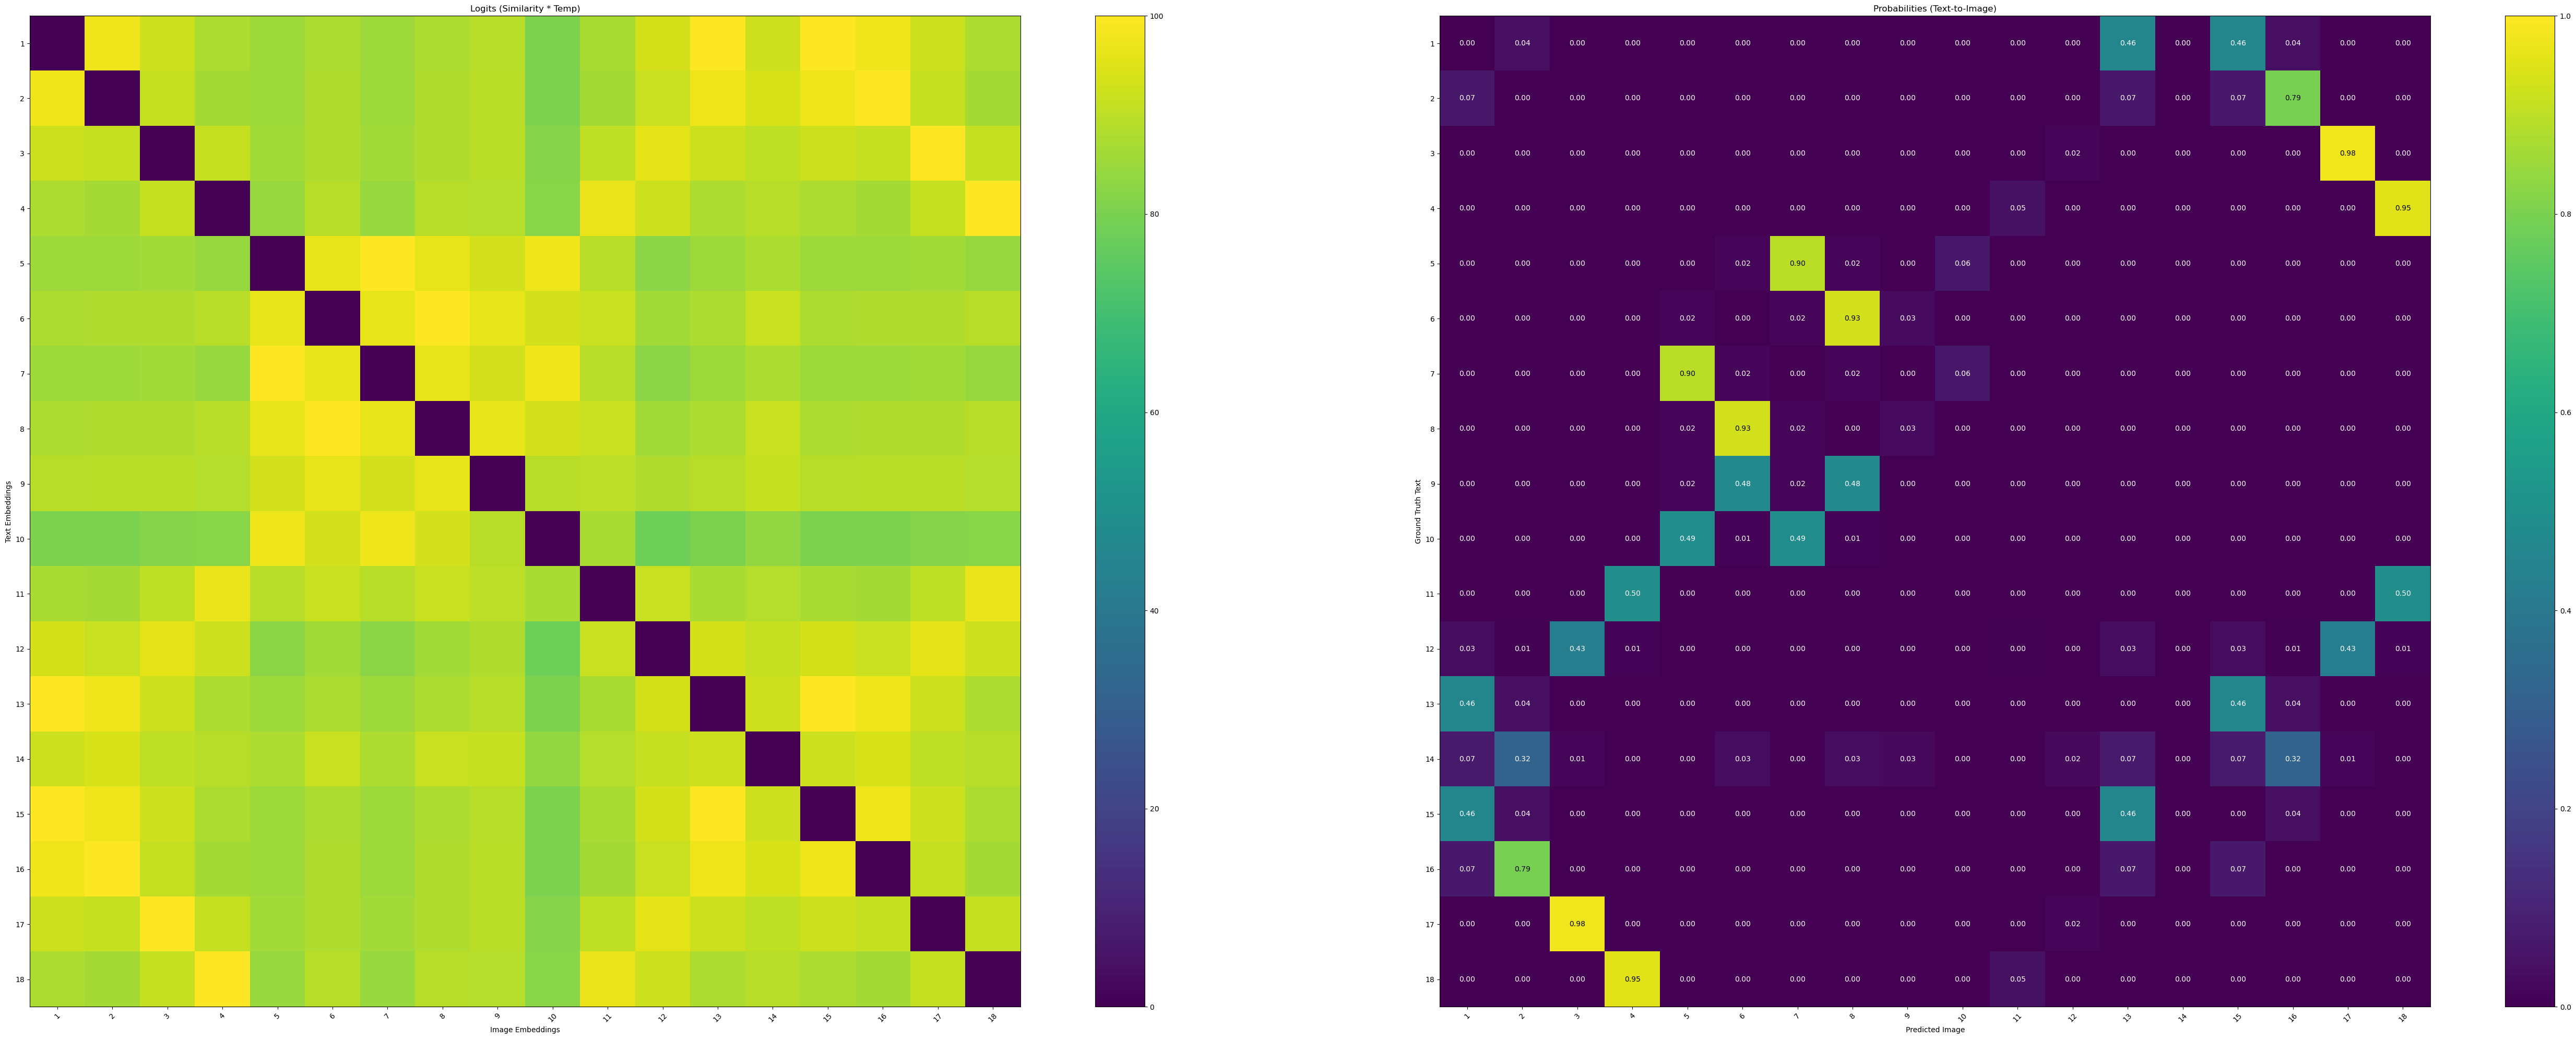

In [87]:
## 7) Visualize the Similarity Matrix and Probabilities

# This cell is fully implemented.
# It visualizes the logits and the resulting probabilities (after softmax)
# to show how the model aligns images and text.

# We need the logits and labels from the previous cell.
if 'logits_per_text' in globals() and 'logits_per_image' in globals():
    
    logits_per_text[range(len(logits_per_text)), range(len(logits_per_text[0]))] = 0
    logits_per_image[range(len(logits_per_image)), range(len(logits_per_image[0]))] = 0
    # Calculate probabilities
    probs_t_i = F.softmax(logits_per_text, dim=1).cpu().detach().numpy()
    probs_i_t = F.softmax(logits_per_image, dim=1).cpu().detach().numpy()
    
    # --- Plot 1: Raw Logits (Similarity) ---
    plt.figure(figsize=(56, 20))
    plt.subplot(1, 2, 1)
    plt.imshow(logits.cpu().detach().numpy(), cmap='viridis')
    plt.title("Logits (Similarity * Temp)")
    plt.xlabel("Image Embeddings")
    plt.ylabel("Text Embeddings")
    plt.xticks(range(N), [f"{i+1}" for i in range(N)], rotation=45)
    plt.yticks(range(N), [f"{i+1}" for i in range(N)])
    plt.colorbar()
    print("Diagonal (Positive Pairs):", [f"{logits[i,i].item():.2f}" for i in range(N)])
    print("Notice the diagonal should have the highest values (brightest squares).")


    # --- Plot 2: Probabilities (Text-to-Image) ---
    plt.subplot(1, 2, 2)
    plt.imshow(probs_t_i, cmap='viridis', vmin=0, vmax=1)
    plt.title("Probabilities (Text-to-Image)")
    plt.xlabel("Predicted Image")
    plt.ylabel("Ground Truth Text")
    plt.xticks(range(N), [f"{i+1}" for i in range(N)], rotation=45)
    plt.yticks(range(N), [f"{i+1}" for i in range(N)])
    plt.colorbar()
    
    # Add text for probabilities
    for i in range(N):
        for j in range(N):
            plt.text(j, i, f"{probs_t_i[i, j]:.2f}", ha='center', va='center', color='white' if probs_t_i[i, j] < 0.5 else 'black')
            
    plt.tight_layout()
    plt.show()

else:
    print("Could not find 'logits_per_text'. Please run the previous cells first.")

In [3]:
import numpy as np

def cosine_similarity_numpy(vec1, vec2):
    """
    Calculate cosine similarity between two 512-dim vectors
    
    Args:
        vec1, vec2: numpy arrays of shape (512,) or (1, 512)
    
    Returns:
        float: Cosine similarity between -1 and 1
    """
    # Ensure vectors are 1D
    vec1 = vec1.flatten()
    vec2 = vec2.flatten()
    
    # Calculate dot product
    dot_product = np.dot(vec1, vec2)
    
    # Calculate magnitudes
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    
    # Handle zero vectors
    if norm1 == 0 or norm2 == 0:
        return 0.0
    
    return dot_product / (norm1 * norm2)

# Example usage with your AI2-THOR embeddings
embedding1 = np.random.randn(512)  # Your actual embedding from the model
embedding2 = np.random.randn(512)  # Another embedding

similarity = cosine_similarity_numpy(embedding1, embedding2)
print(f"Similarity: {similarity:.4f}")
#print(img0)
img0 = image_embeds[0]
img1 = image_embeds[7]

img0 = img0.cpu().numpy()
img1 = img1.cpu().numpy()
#img1.toNumpy()
#img0.reshape(-1)
#print(embedding1)
similarity = cosine_similarity_numpy(img0, img1)
print(f"Similarity: {similarity:.4f}")

#print(embedding1.shape, img0.reshape(-1))

Similarity: -0.0612


NameError: name 'image_embeds' is not defined

In [51]:
img0 = image_embeds_norm[5]
img1 = image_embeds_norm[4]

similarity = img0 @ img1.T
print(similarity)
probs = F.softmax(similarity)
print(probs)

tensor(1., device='cuda:0')
tensor(1., device='cuda:0')


/tmp/ipykernel_8970/1412740295.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(similarity)


In [52]:
img0 = image_embeds[0]
img1 = image_embeds[7]

img0 = img0.cpu().numpy()
img1 = img1.cpu().numpy()
#img1.toNumpy()
#img0.reshape(-1)
#print(embedding1)
similarity = cosine_similarity_numpy(img0, img1)
print(f"Similarity: {similarity:.4f}")

Similarity: 0.9123


In [10]:
import torch
import numpy as np

class DistributionConfidence:
    def __init__(self):
        pass

    def agent_decision(self, analysis):
        """
        Make decisions based on confidence analysis
        """
        if analysis['combined_score'] > 0.8:
            # Very confident - trust the match
            return "E", analysis['peak_index']
        
        elif analysis['combined_score'] > 0.5:
            # Moderately confident - useful but be cautious
            return "P1", analysis['peak_index']
        
        elif analysis['peak_to_wall_ratio'] > 5:
            # Strong single peak despite lower combined score
            return "P2", analysis['peak_index']
        
        else:
            # Not confident - don't rely on this match
            return "U", None
    
    def analyze(self, probs):
        """
        Analyze a probability distribution and return multiple confidence metrics.
        
        Args:
            probs: torch.Tensor of probability values
            
        Returns:
            dict with various confidence scores
        """
        probs = probs / probs.sum()  # Ensure valid distribution
        peak_val, peak_idx = torch.max(probs, dim=0)
        
        # Individual metrics
        peak_conf = peak_val.item()
        entropy = self._entropy(probs)
        ipr = self._ipr(probs)
        peak_to_wall = self._peak_to_wall(probs, peak_idx)
        kl_uniform = self._kl_from_uniform(probs)
        
        # Normalized metrics (0-1 scale)
        n_components = len(probs)
        max_entropy = np.log(n_components)  # For uniform distribution
        normalized_entropy = 1 - (entropy / max_entropy)  # Higher = more confident
        
        max_ipr = 1.0  # One peak at 1.0
        min_ipr = 1.0 / n_components  # Uniform distribution
        normalized_ipr = (ipr - min_ipr) / (max_ipr - min_ipr)
        
        # Combined confidence score (weighted average)
        combined_score = (
            peak_conf * 0.3 +
            normalized_entropy * 0.2 +
            normalized_ipr * 0.2 +
            min(peak_to_wall / 10, 1.0) * 0.2 +  # Cap at 1.0
            min(kl_uniform / 2, 1.0) * 0.1
        )
        
        return {
            'peak_confidence': peak_conf,
            'peak_index': peak_idx.item(),
            'entropy': entropy,
            'normalized_entropy': normalized_entropy,
            'ipr': ipr,
            'normalized_ipr': normalized_ipr,
            'peak_to_wall_ratio': peak_to_wall,
            'kl_from_uniform': kl_uniform,
            'combined_score': combined_score,
            'is_confident': combined_score > 0.7  # Adjust threshold as needed
        }
    
    def _entropy(self, probs):
        """Calculate Shannon entropy"""
        probs = probs[probs > 0]
        return -torch.sum(probs * torch.log(probs)).item()
    
    def _ipr(self, probs):
        """Calculate Inverse Participation Ratio"""
        return torch.sum(probs ** 2).item()
    
    def _peak_to_wall(self, probs, peak_idx):
        """Calculate peak-to-wall ratio"""
        peak = probs[peak_idx]
        other_probs = torch.cat([probs[:peak_idx], probs[peak_idx+1:]])
        mean_other = torch.mean(other_probs)
        return (peak / mean_other).item()
    
    def _kl_from_uniform(self, probs):
        """Calculate KL divergence from uniform distribution"""
        n = len(probs)
        uniform = torch.ones(n) / n
        kl = torch.sum(probs * torch.log(probs / uniform))
        return kl.item()

    def path_continuity(self, fittings):
        """
        Estimate how continuous is the path. E.g., [1,2,3,4] is continuous, [1,2,-1,4] is less so and [1,-1,1,4] is not continuous.
        """
        fitting_p = -1
        fitting_pp = -1
        fitting_c = -1
        score_good = 0
        score_cnt = 0
    
        for i in range(len(fittings)):
            # If current index is 0, then we can't evaluate the fitting
            if i > 0:
                # If current fitting is previous + 1 or prev previous + 2, then that's good
                if (fittings[i] == fitting_p + 1) or (fittings[i] == fitting_pp + 2):
                    score_good += 1
                score_cnt += 1
                
            fitting_pp = fitting_p
            fitting_p = fittings[i]
    
        return (score_good / score_cnt)

# Example usage
confidence = DistributionConfidence()

dist1 = torch.tensor([0.01, 0.01, 0.90, 0.04, 0.04])
dist2 = torch.tensor([0.2, 0.35, 0.36, 0.15, 0.12])

print("Distribution 1 Analysis:")
print(confidence.analyze(dist1))
print("decision: ", confidence.agent_decision(confidence.analyze(dist1)))
print("\nDistribution 2 Analysis:")
print(confidence.analyze(dist2))
print("decision: ", confidence.agent_decision(confidence.analyze(dist2)))

Distribution 1 Analysis:
{'peak_confidence': 0.8999999761581421, 'peak_index': 2, 'entropy': 0.4444379508495331, 'normalized_entropy': 0.7238551748930974, 'ipr': 0.8133999705314636, 'normalized_ipr': 0.7667499631643295, 'peak_to_wall_ratio': 36.0, 'kl_from_uniform': 1.1649999618530273, 'combined_score': 0.8263710185515794, 'is_confident': True}
decision:  ('E', 2)

Distribution 2 Analysis:
{'peak_confidence': 0.305084764957428, 'peak_index': 2, 'entropy': 1.5181580781936646, 'normalized_entropy': 0.0567153498343933, 'ipr': 0.23628267645835876, 'normalized_ipr': 0.04535334557294844, 'peak_to_wall_ratio': 1.7560975551605225, 'kl_from_uniform': 0.09127992391586304, 'combined_score': 0.15162511586770033, 'is_confident': False}
decision:  ('U', None)


In [11]:
import os, glob, re
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

class PathCompare:
    def __init__(self):
        self.device = "cuda:0"
        # We will use the base model from OpenAI, loaded via Hugging Face.
        model_name = "openai/clip-vit-base-patch32"
        # The CLIPProcessor handles both image preprocessing (resizing, normalizing)
        # and text tokenization.
        self.processor = CLIPProcessor.from_pretrained(model_name)
        # The CLIPModel contains:
        # 1. model.get_text_features()
        # 2. model.get_image_features()
        # although we realistically will only need image one
        self.model = CLIPModel.from_pretrained(model_name).to(self.device)
        print("CLIP Processor and Model loaded successfully.")
        self.confidence = DistributionConfidence()

    def extract_number(self, filename):
        # Extract the number from the filename (assuming it's the step count)
        # This regex looks for digits at the beginning, end, or between non-digits
        numbers = re.findall(r'\d+', filename)
        return int(numbers[-1]) if numbers else 0

    def load_images(self, path):
        imgs_path = glob.glob(path)
        imgs_path = sorted(imgs_path, key=self.extract_number)
        print(imgs_path)
        pil_images = [Image.open(fname).convert('RGB') for fname in imgs_path]
        return pil_images
    
    def load_ref_path(self):
        return self.load_images("/ae_path_compare/1/*.png")

    def load_cur_path(self):
        return self.load_images("/ae_path_compare/tmp_cmp_s2/*.png")

    def load_alien_path(self):
        return self.load_images("/ae_path_compare/tmp_cmp_C/*.png")
    
    def compare_paths(self, ref_path, cur_path):
        captions = [""]
        ref_path_inputs = self.processor(text=captions, images=ref_path, return_tensors="pt", padding=True)
        cur_path_inputs = self.processor(text=captions, images=cur_path, return_tensors="pt", padding=True)
        
        ref_path_inputs = {k: v.to(self.device) for k, v in ref_path_inputs.items()} # Move to device
        cur_path_inputs = {k: v.to(self.device) for k, v in cur_path_inputs.items()} # Move to device
        
        # get embeddings
        with torch.no_grad():
            ref_path_outputs = self.model(**ref_path_inputs)
            ref_path_embeds = ref_path_outputs.image_embeds
            cur_path_outputs = self.model(**cur_path_inputs)
            cur_path_embeds = cur_path_outputs.image_embeds

        #print(ref_path_embeds)
        
        ideal_path_normalized = F.normalize(ref_path_embeds, dim=1)
        current_path_normalized = F.normalize(cur_path_embeds, dim=1)
        
        # Get similarity to all reference frames in one matrix multiplication
        similarities = torch.mm(current_path_normalized, ideal_path_normalized.t()).squeeze()

        logit_scale = self.model.logit_scale.exp()
        logits = similarities * logit_scale
        #logits[range(len(logits)), range(len(logits[0]))] = 0 # we're not interested in each image compared to itself, so set the diagonal to 0
        # 4. Convert logits to probabilities using Softmax
        probs = F.softmax(logits, dim=-1)
        return probs

    def fit_single_img_to_ref_path(self, ref_path, img):
        probs = self.compare_paths(ref_path, [img])
        #print("Distribution 1 Analysis:")
        #print(confidence.analyze(dist1))
        #print("decision: ", confidence.agent_decision(confidence.analyze(dist1)))
        probs = probs.cpu().detach()
        dec = self.confidence.agent_decision(self.confidence.analyze(probs))
        return dec

    def fit_cur_path_to_ref_path(self, ref_path, cur_path):
        fittings = [self.fit_single_img_to_ref_path(ref_path, cp) for cp in cur_path]
        ft = [f[1] if f[0]!='U' else -1 for f in fittings]
        cont = self.confidence.path_continuity(ft)
        return fittings, cont
            
    
    def visualize_probs(self, probs):
        # To accomodate probs having only 1 dimension because we only compare 1 image against a whole reference path, we need to check shape and unsqueeze if needed
        if len(probs.shape) == 1:
            probs = probs.unsqueeze(dim=0)
        rows = probs.shape[0]
        cols = probs.shape[1]
        probs = probs.cpu().detach().numpy()
        plt.figure(figsize=(56, 20))
        plt.subplot(1, 2, 2)
        plt.imshow(probs, cmap='viridis', vmin=0, vmax=1)
        plt.title("Path image similarities")
        plt.xlabel("Reference path")
        plt.ylabel("Current path")
        plt.xticks(range(cols), [f"{i+1}" for i in range(cols)], rotation=45)
        plt.yticks(range(rows), [f"{i+1}" for i in range(rows)])
        plt.colorbar()
        
        # Add text for probabilities
        for i in range(rows):
            for j in range(cols):
                plt.text(j, i, f"{probs[i, j]:.2f}", ha='center', va='center', color='white' if probs[i, j] < 0.5 else 'black')
                
        plt.tight_layout()
        plt.show()

pc = PathCompare()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP Processor and Model loaded successfully.


In [14]:
ref_imgs = pc.load_ref_path()
cur_imgs = pc.load_cur_path()
alien_imgs = pc.load_alien_path()

fittings = pc.fit_cur_path_to_ref_path(ref_imgs, cur_imgs)
print(fittings)
ft = [f[1] if f[0]!='U' else -1 for f in fittings[0]]
print(ft, confidence.path_continuity(ft))

fittings = pc.fit_cur_path_to_ref_path(ref_imgs, alien_imgs)
print(fittings)
ft = [f[1] if f[0]!='U' else -1 for f in fittings[0]]
print(ft, confidence.path_continuity(ft))

['/ae_path_compare/1/1.png', '/ae_path_compare/1/2.png', '/ae_path_compare/1/3.png', '/ae_path_compare/1/4.png', '/ae_path_compare/1/5.png', '/ae_path_compare/1/6.png', '/ae_path_compare/1/7.png', '/ae_path_compare/1/8.png', '/ae_path_compare/1/9.png', '/ae_path_compare/1/10.png']
['/ae_path_compare/tmp_cmp_s2/1.png', '/ae_path_compare/tmp_cmp_s2/2.png', '/ae_path_compare/tmp_cmp_s2/3.png', '/ae_path_compare/tmp_cmp_s2/4.png', '/ae_path_compare/tmp_cmp_s2/5.png', '/ae_path_compare/tmp_cmp_s2/6.png', '/ae_path_compare/tmp_cmp_s2/7.png', '/ae_path_compare/tmp_cmp_s2/8.png']
['/ae_path_compare/tmp_cmp_C/1.png', '/ae_path_compare/tmp_cmp_C/2.png', '/ae_path_compare/tmp_cmp_C/3.png', '/ae_path_compare/tmp_cmp_C/4.png', '/ae_path_compare/tmp_cmp_C/5.png']
([('U', None), ('U', None), ('U', None), ('U', None), ('U', None), ('U', None), ('U', None), ('U', None)], 0.0)
[-1, -1, -1, -1, -1, -1, -1, -1] 0.0
([('U', None), ('U', None), ('U', None), ('U', None), ('U', None)], 0.0)
[-1, -1, -1, -1, -

['/ae_path_compare/1/1.png', '/ae_path_compare/1/2.png', '/ae_path_compare/1/3.png', '/ae_path_compare/1/4.png', '/ae_path_compare/1/5.png', '/ae_path_compare/1/6.png', '/ae_path_compare/1/7.png', '/ae_path_compare/1/8.png', '/ae_path_compare/1/9.png', '/ae_path_compare/1/10.png']
['/ae_path_compare/tmp_cmp_s2/1.png', '/ae_path_compare/tmp_cmp_s2/2.png', '/ae_path_compare/tmp_cmp_s2/3.png', '/ae_path_compare/tmp_cmp_s2/4.png', '/ae_path_compare/tmp_cmp_s2/5.png', '/ae_path_compare/tmp_cmp_s2/6.png', '/ae_path_compare/tmp_cmp_s2/7.png', '/ae_path_compare/tmp_cmp_s2/8.png']
['/ae_path_compare/tmp_cmp_C/1.png', '/ae_path_compare/tmp_cmp_C/2.png', '/ae_path_compare/tmp_cmp_C/3.png', '/ae_path_compare/tmp_cmp_C/4.png', '/ae_path_compare/tmp_cmp_C/5.png']
torch.Size([8, 10])


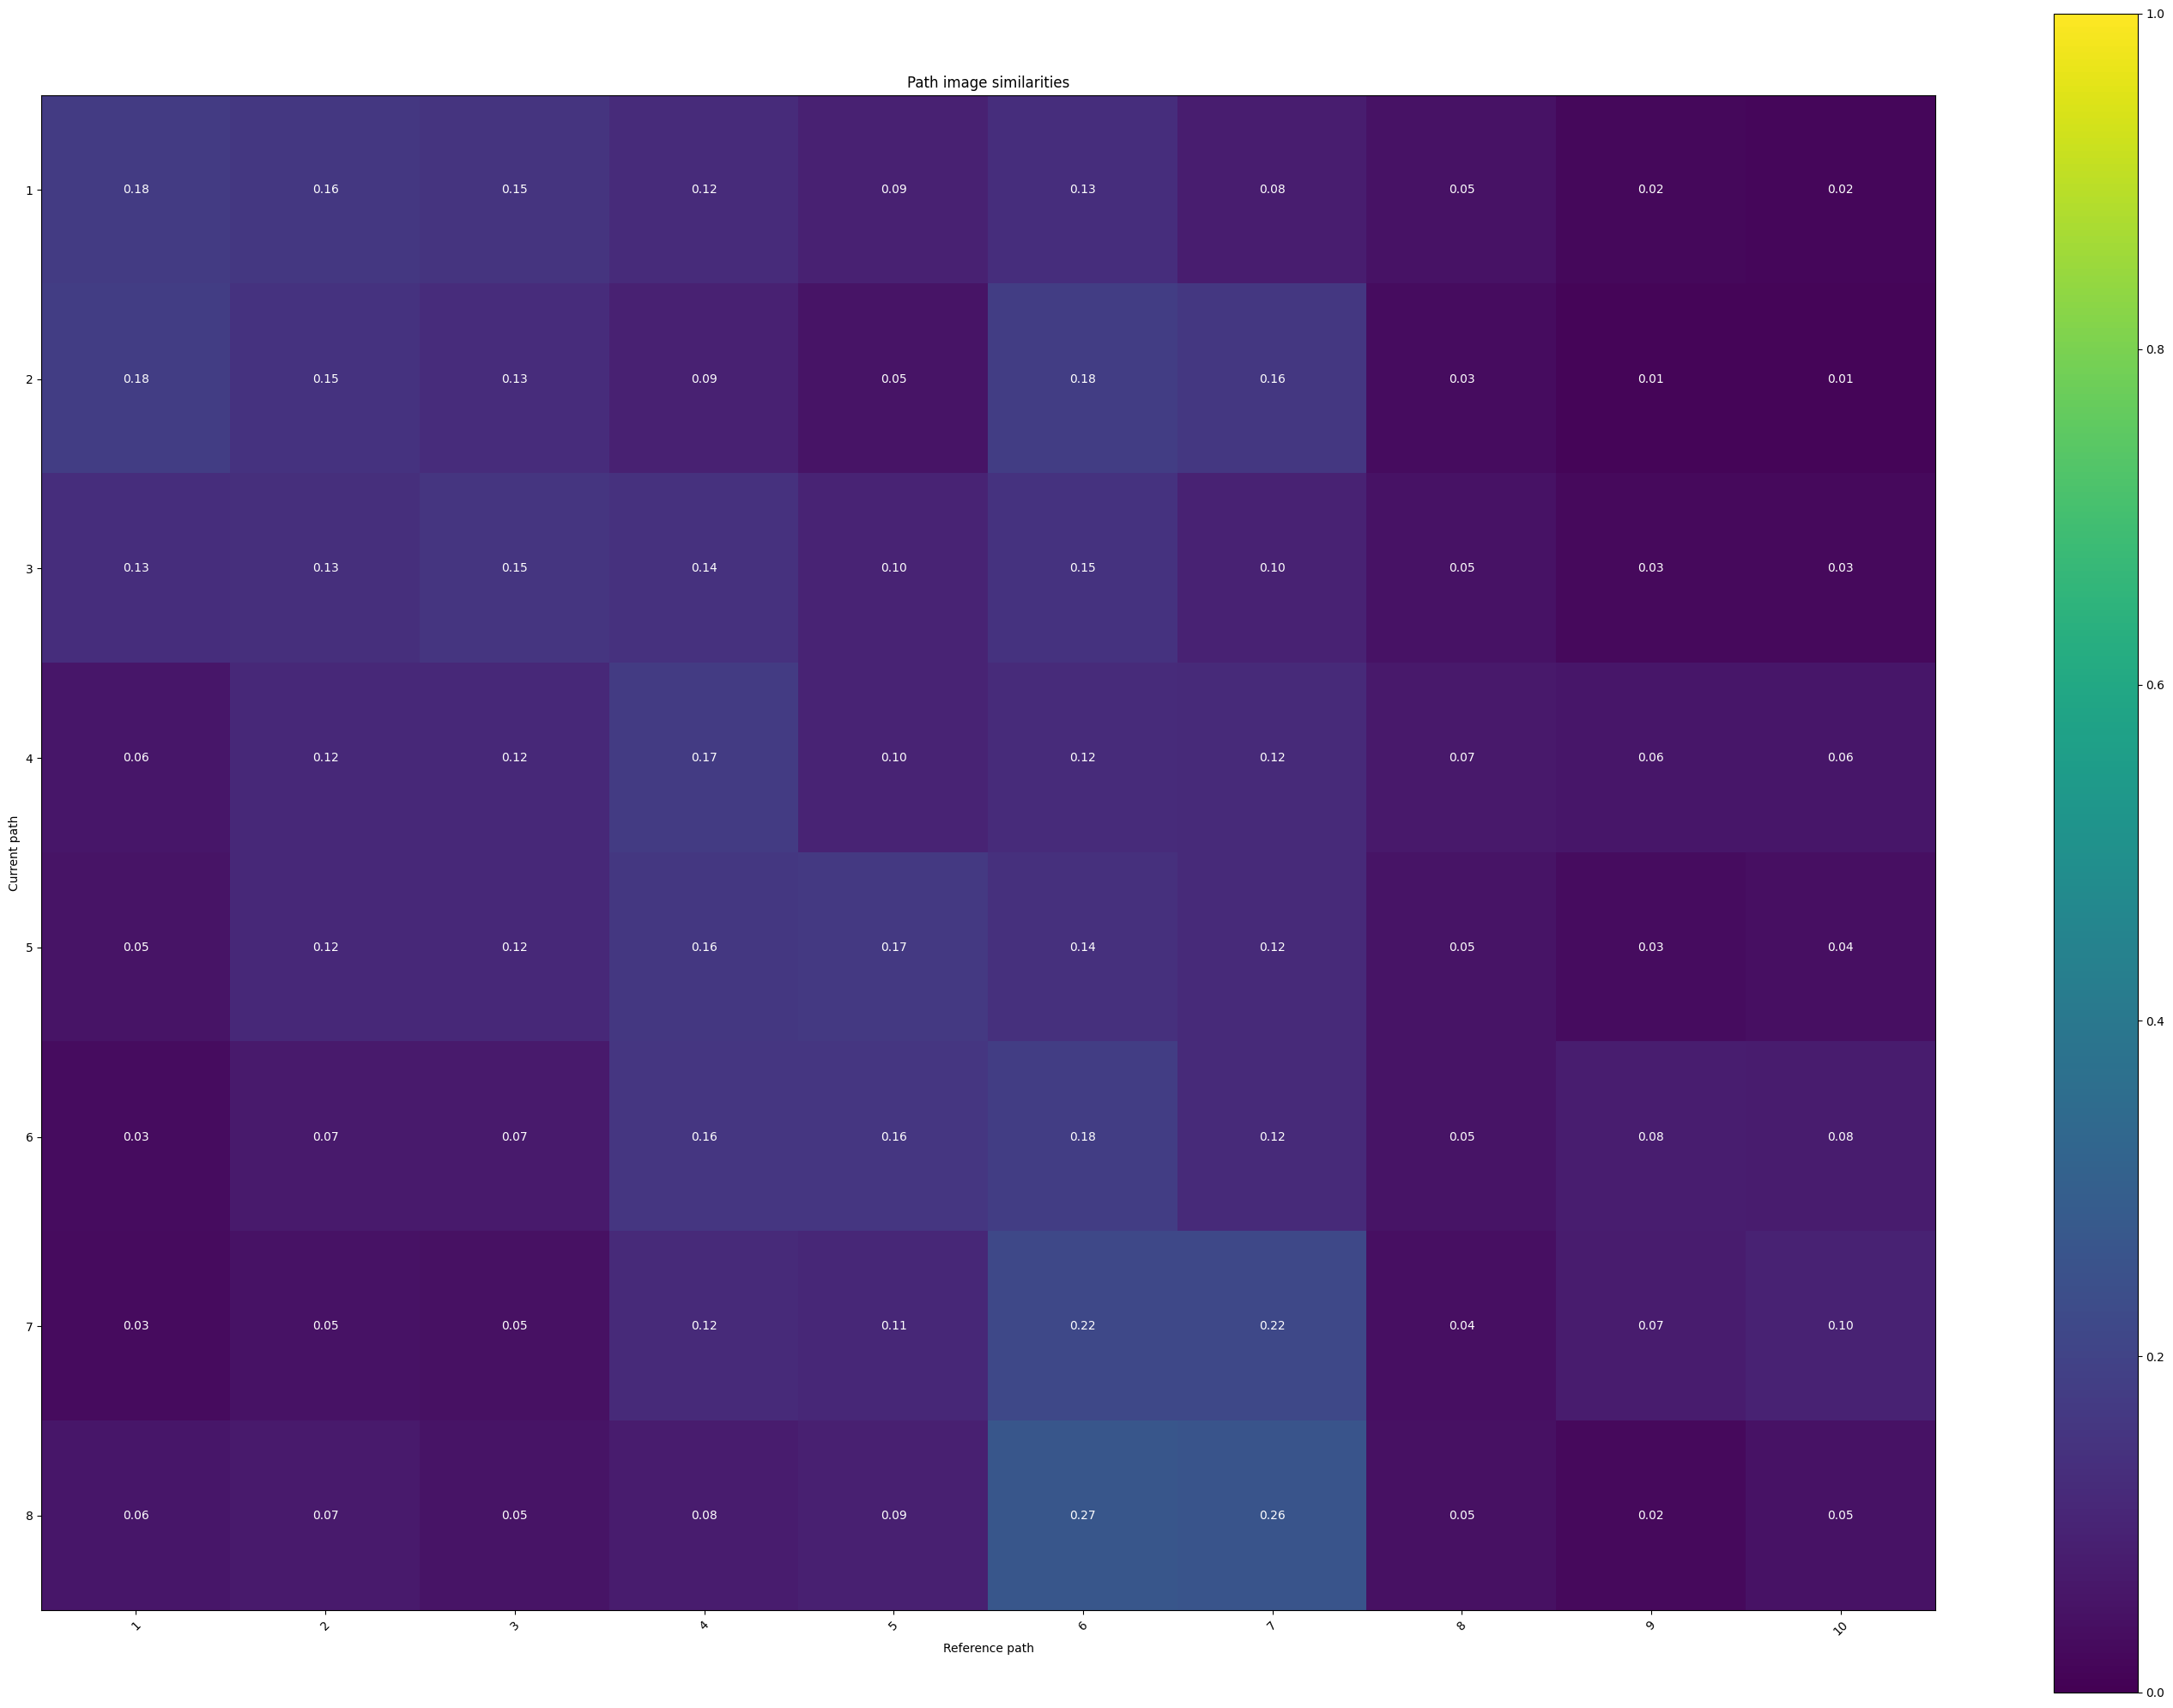

In [16]:
ref_imgs = pc.load_ref_path()
cur_imgs = pc.load_cur_path()
alien_imgs = pc.load_alien_path()

#probs = pc.compare_paths(ref_imgs, alien_imgs)
probs = pc.compare_paths(ref_imgs, cur_imgs)
print(probs.shape)
pc.visualize_probs(probs)

In [24]:
ref_path = ref_imgs
cur_path = cur_imgs[4:5]

captions = [""]
ref_path_inputs = pc.processor(text=captions, images=ref_path, return_tensors="pt", padding=True)
cur_path_inputs = pc.processor(text=captions, images=cur_path, return_tensors="pt", padding=True)

ref_path_inputs = {k: v.to(pc.device) for k, v in ref_path_inputs.items()} # Move to device
cur_path_inputs = {k: v.to(pc.device) for k, v in cur_path_inputs.items()} # Move to device

# get embeddings
with torch.no_grad():
    ref_path_outputs = pc.model(**ref_path_inputs)
    ref_path_embeds = ref_path_outputs.image_embeds
    cur_path_outputs = pc.model(**cur_path_inputs)
    cur_path_embeds = cur_path_outputs.image_embeds

#print(ref_path_embeds)

ideal_path_normalized = F.normalize(ref_path_embeds, dim=1)
current_path_normalized = F.normalize(cur_path_embeds, dim=1)

# Get similarity to all reference frames in one matrix multiplication
similarities = torch.mm(current_path_normalized, ideal_path_normalized.t()).squeeze()

logit_scale = pc.model.logit_scale.exp()
logits = similarities * logit_scale
print(logits.shape)
#logits[range(len(logits)), range(len(logits[0]))] = 0 # we're not interested in each image compared to itself, so set the diagonal to 0
# 4. Convert logits to probabilities using Softmax
probs = F.softmax(logits, dim=-1)
print(probs)
print(torch.argmax(probs, dim=-1).item())

torch.Size([9])
tensor([1.4065e-01, 5.9921e-01, 1.2869e-01, 5.3422e-02, 5.8340e-04, 5.3162e-02,
        2.2830e-02, 7.4732e-04, 7.0718e-04], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
1


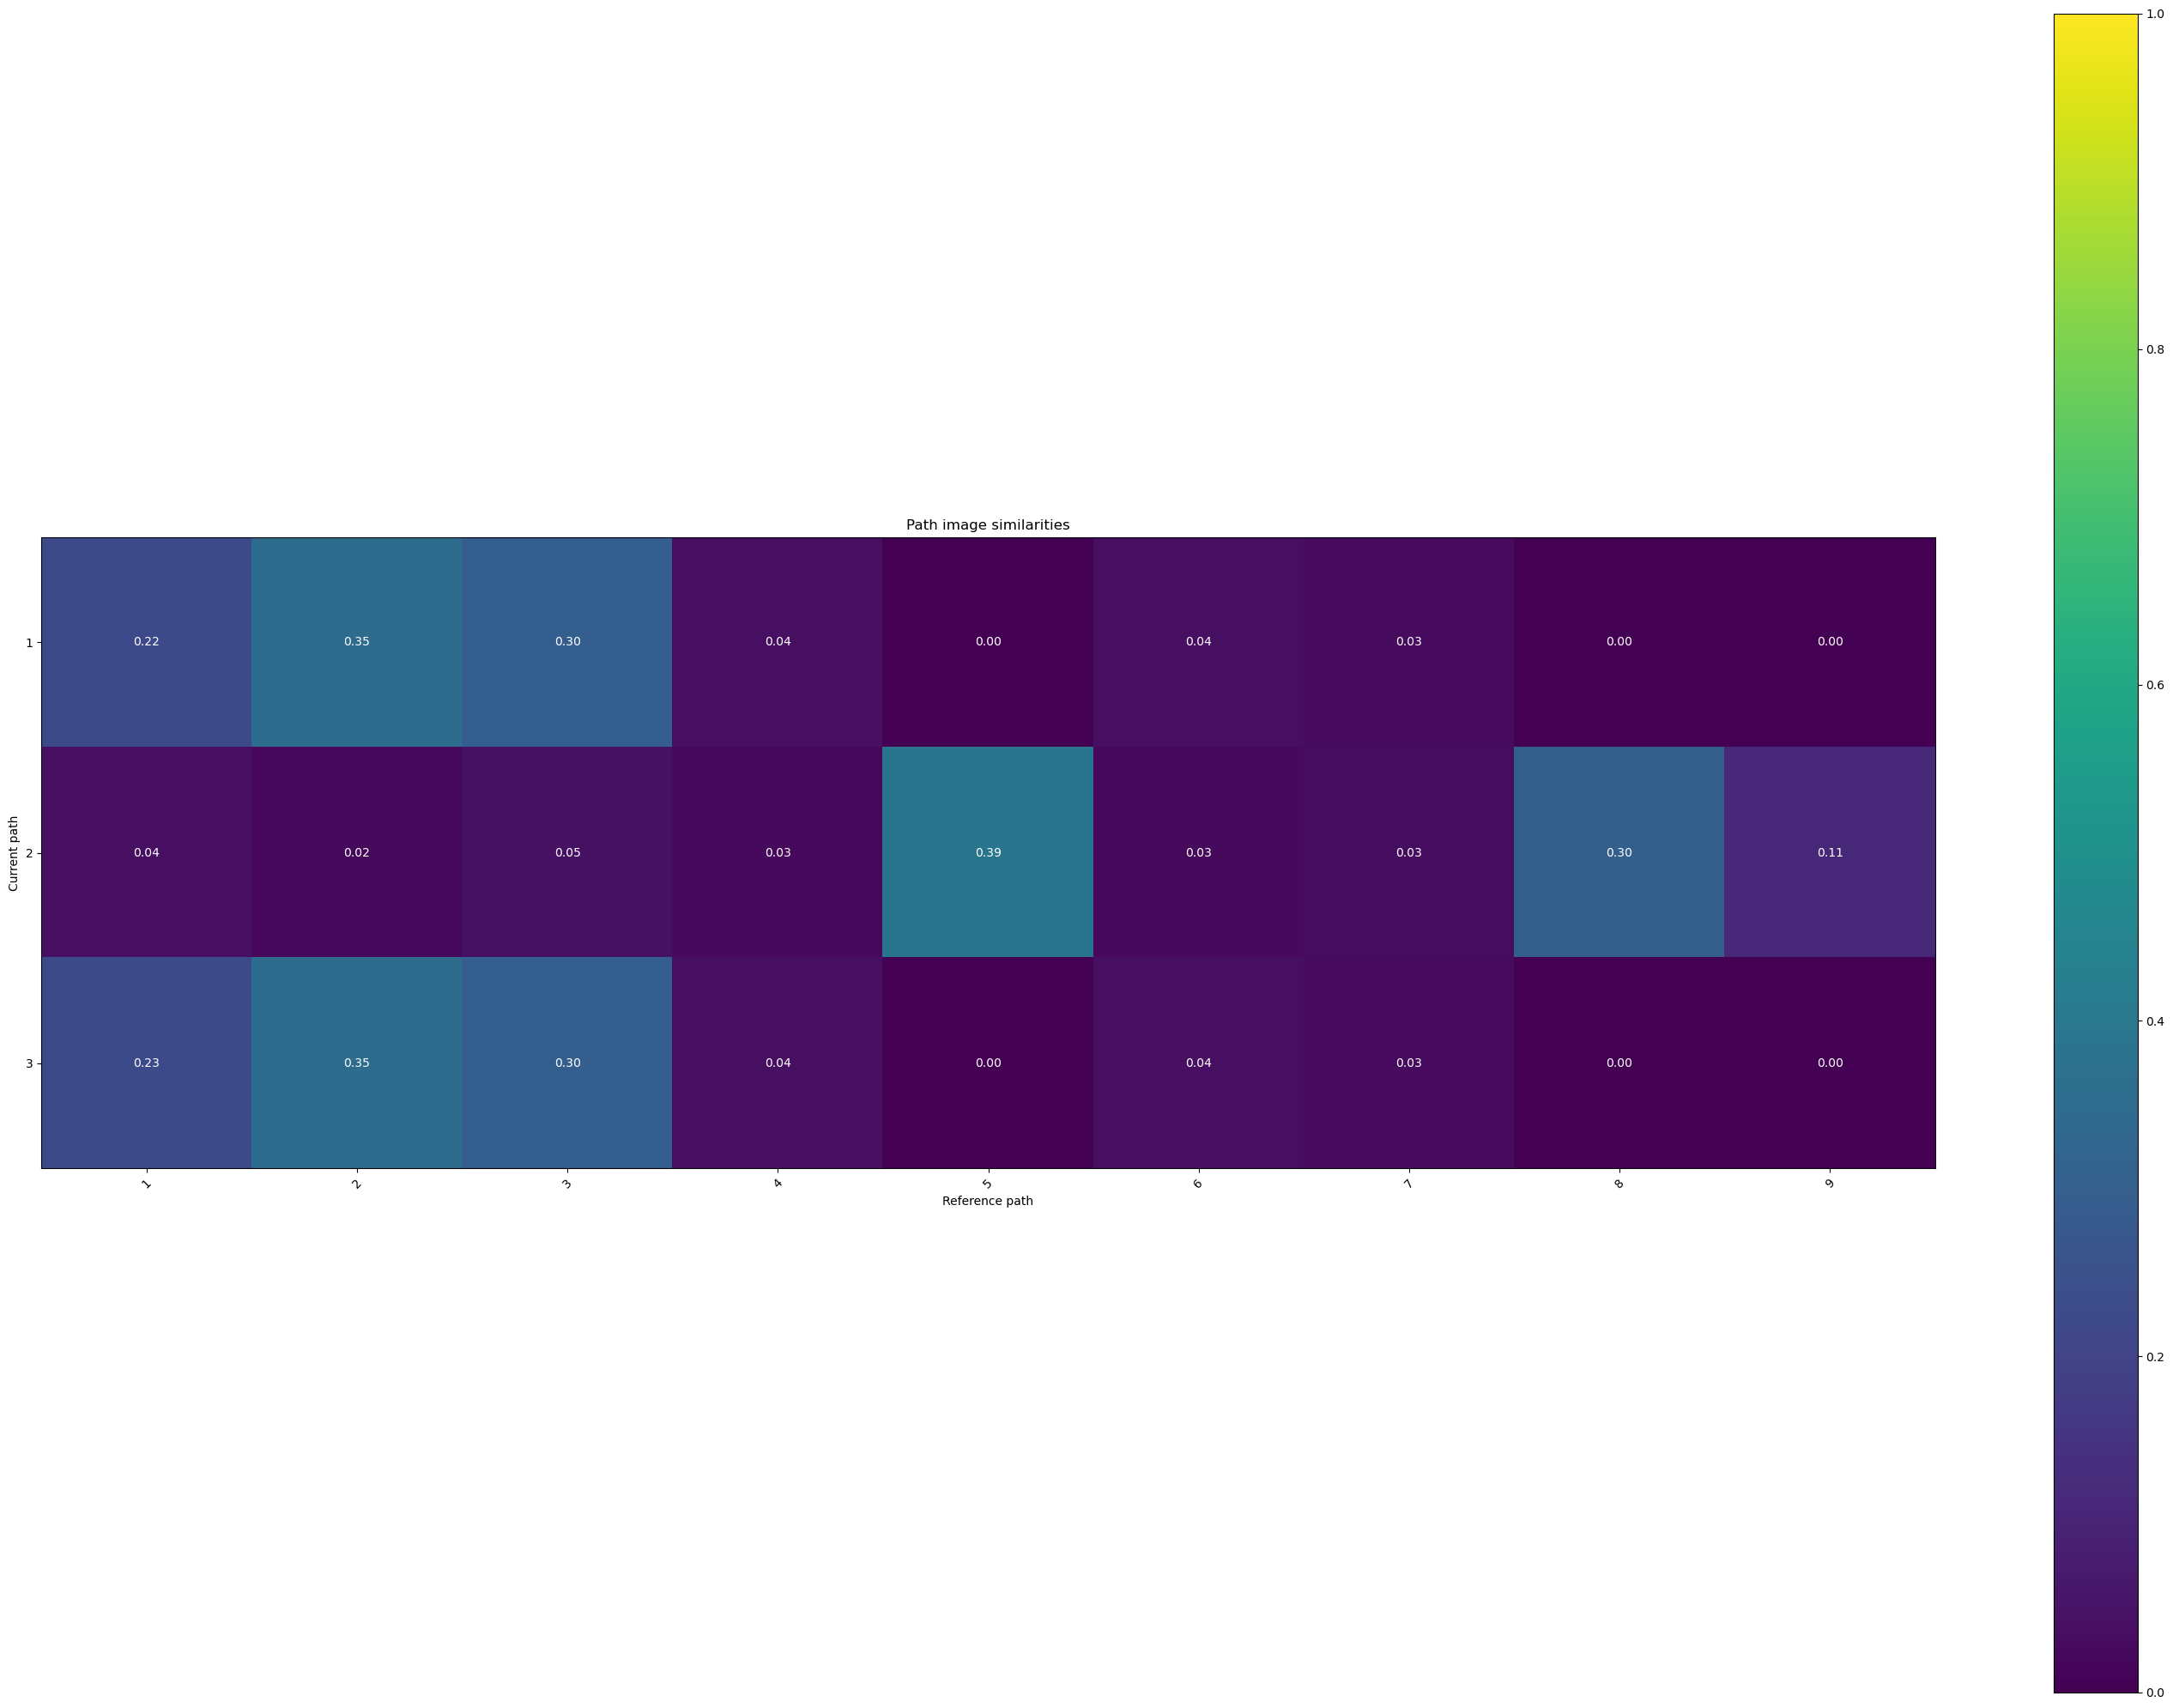

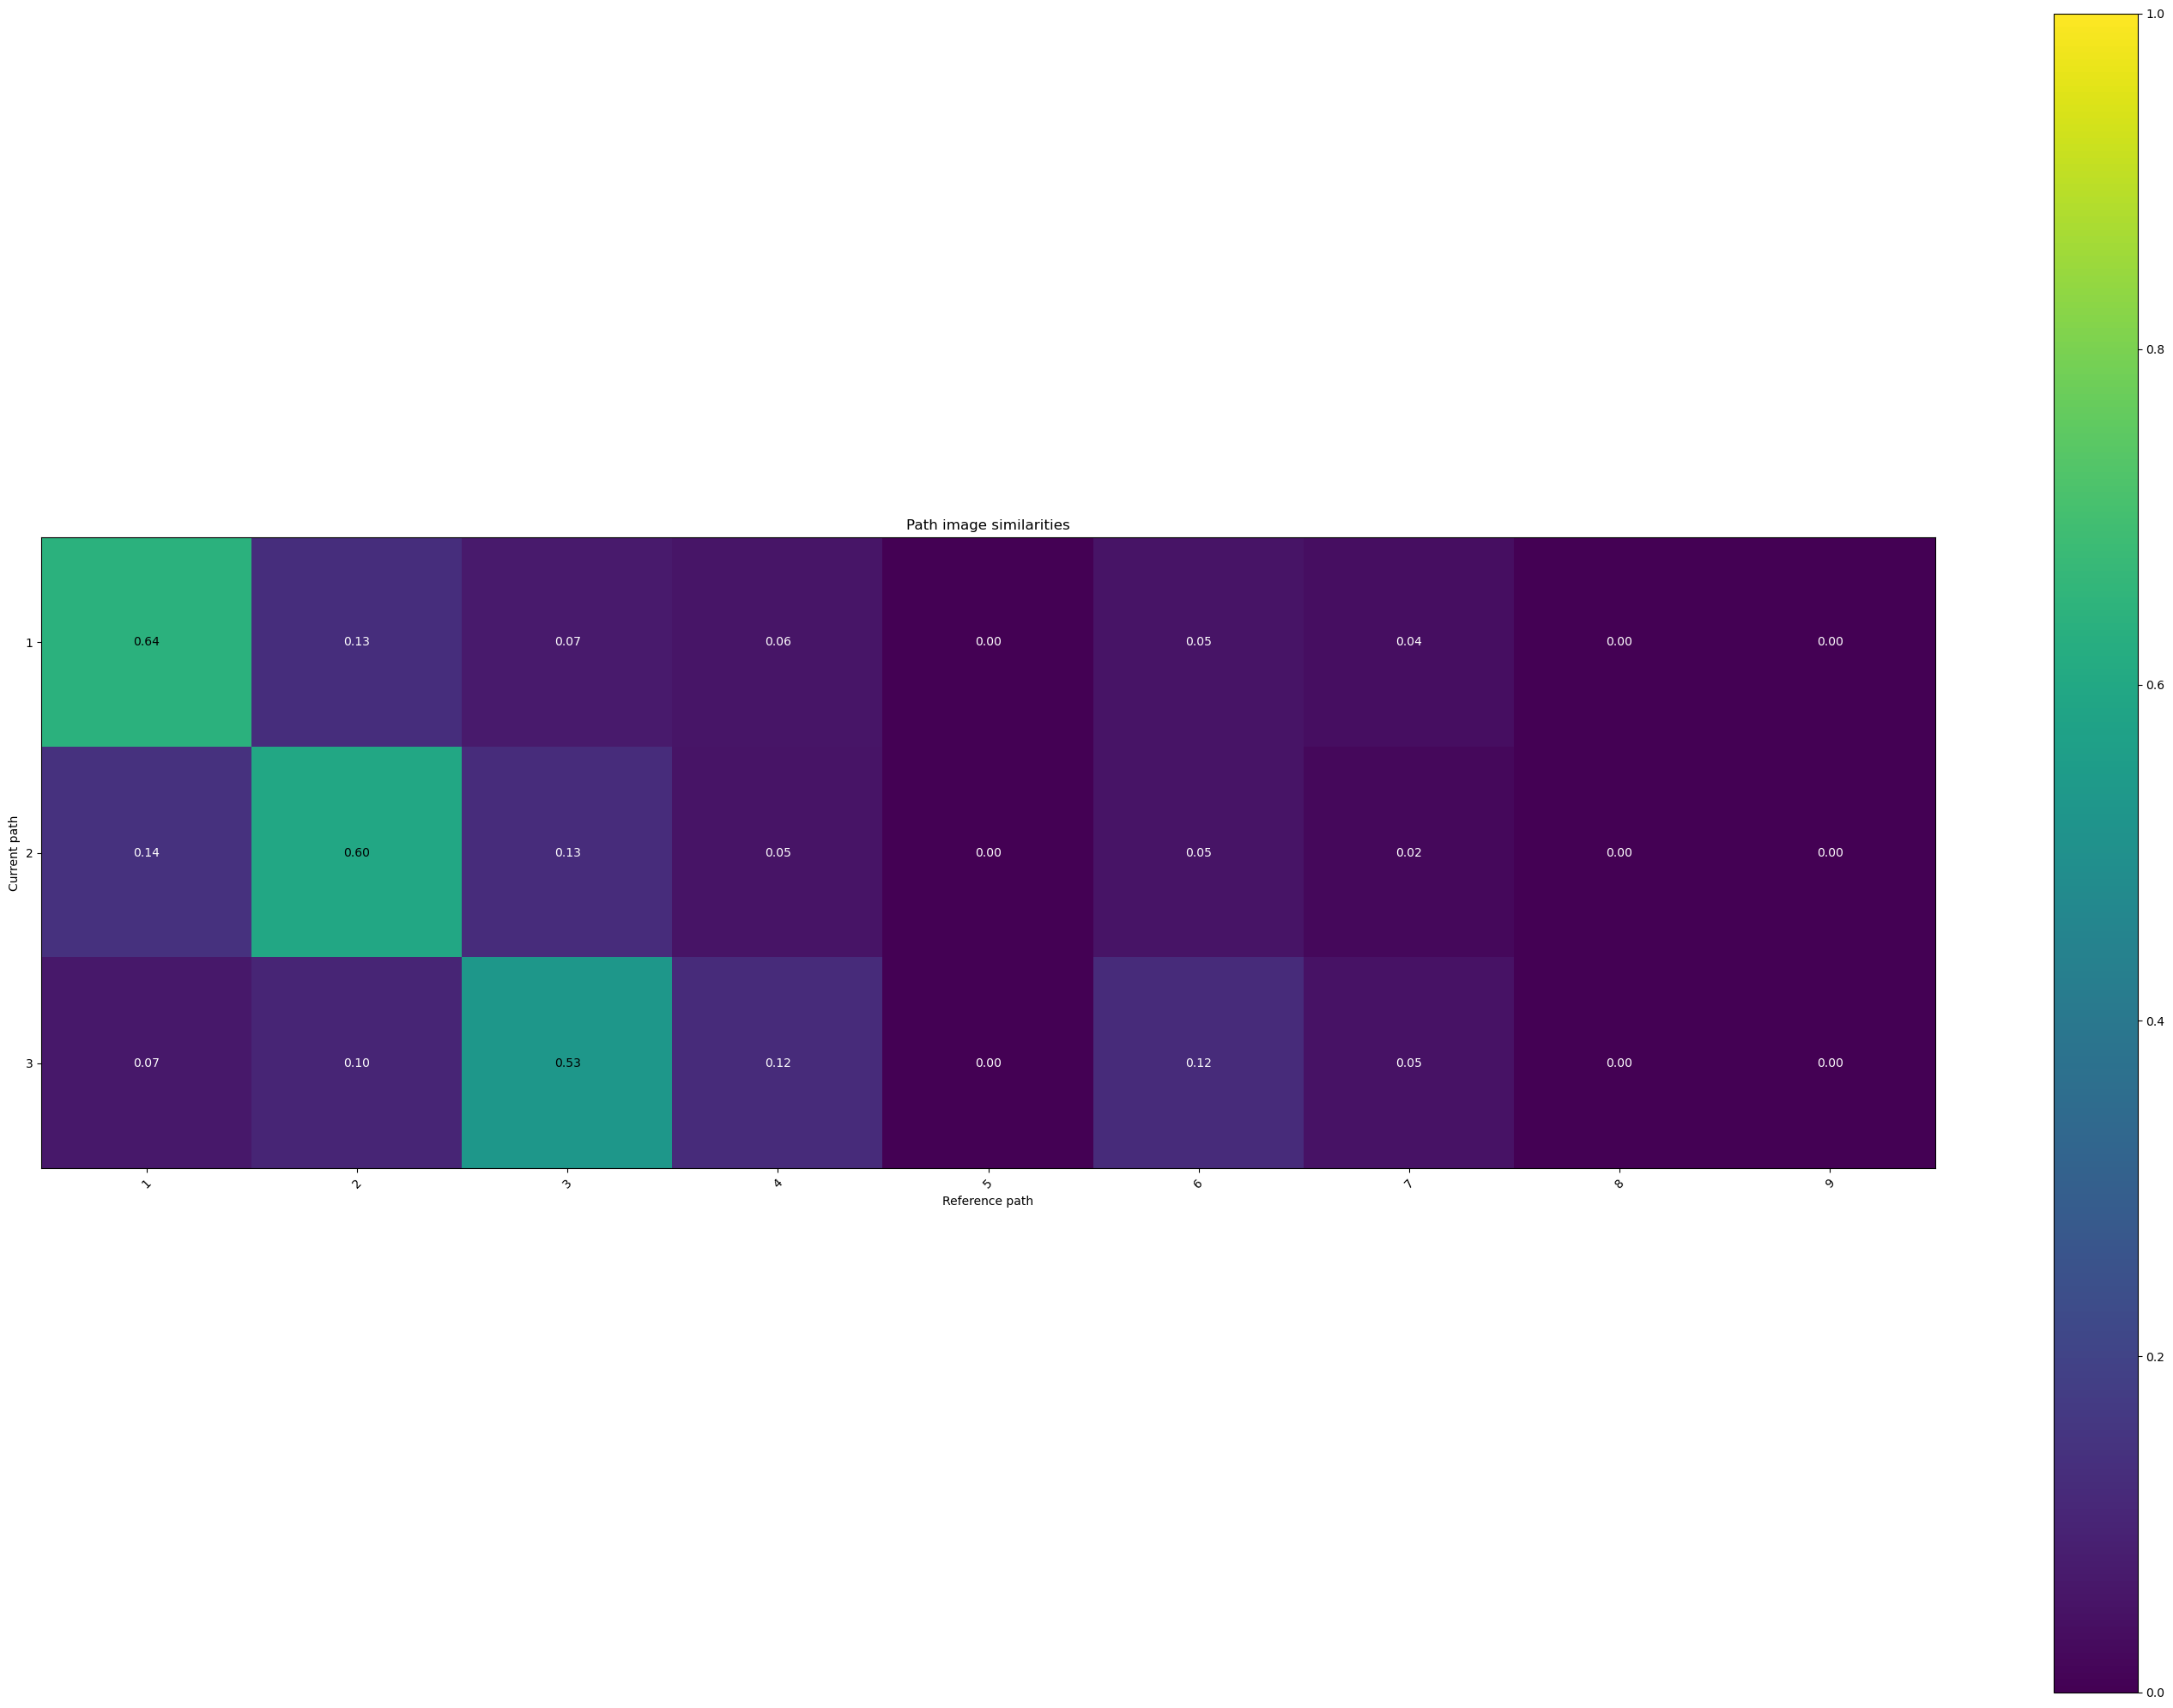

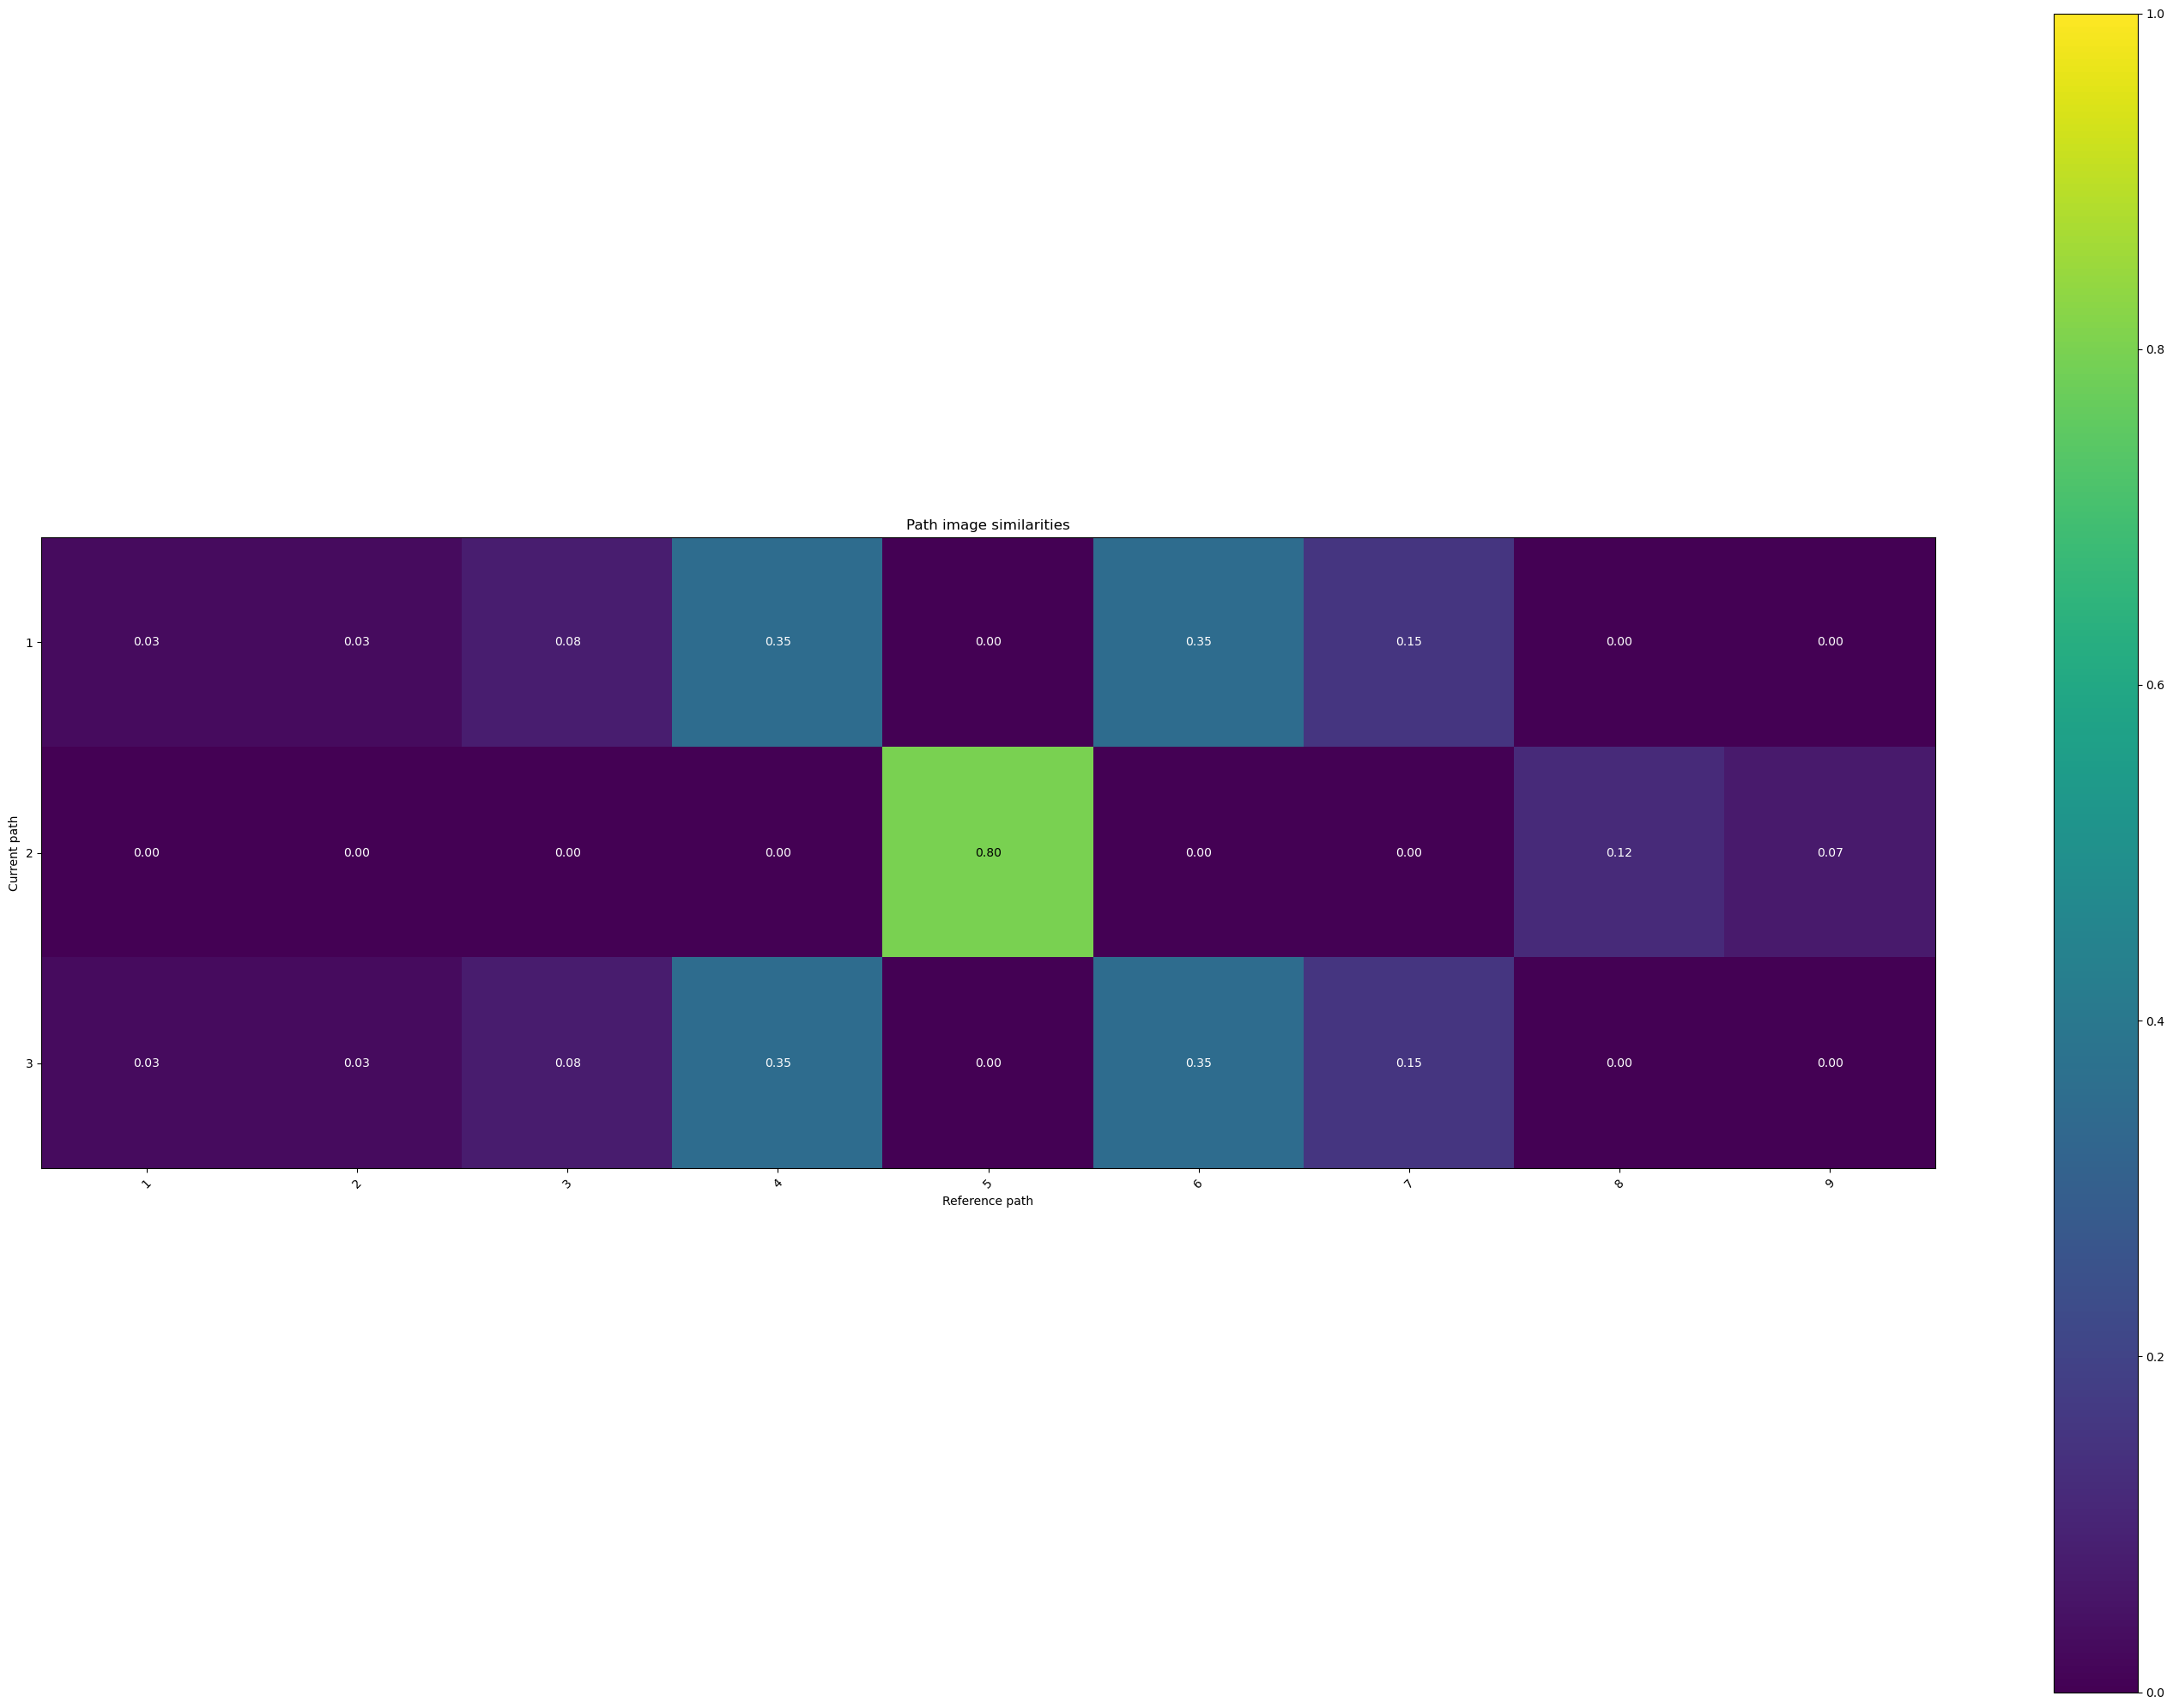

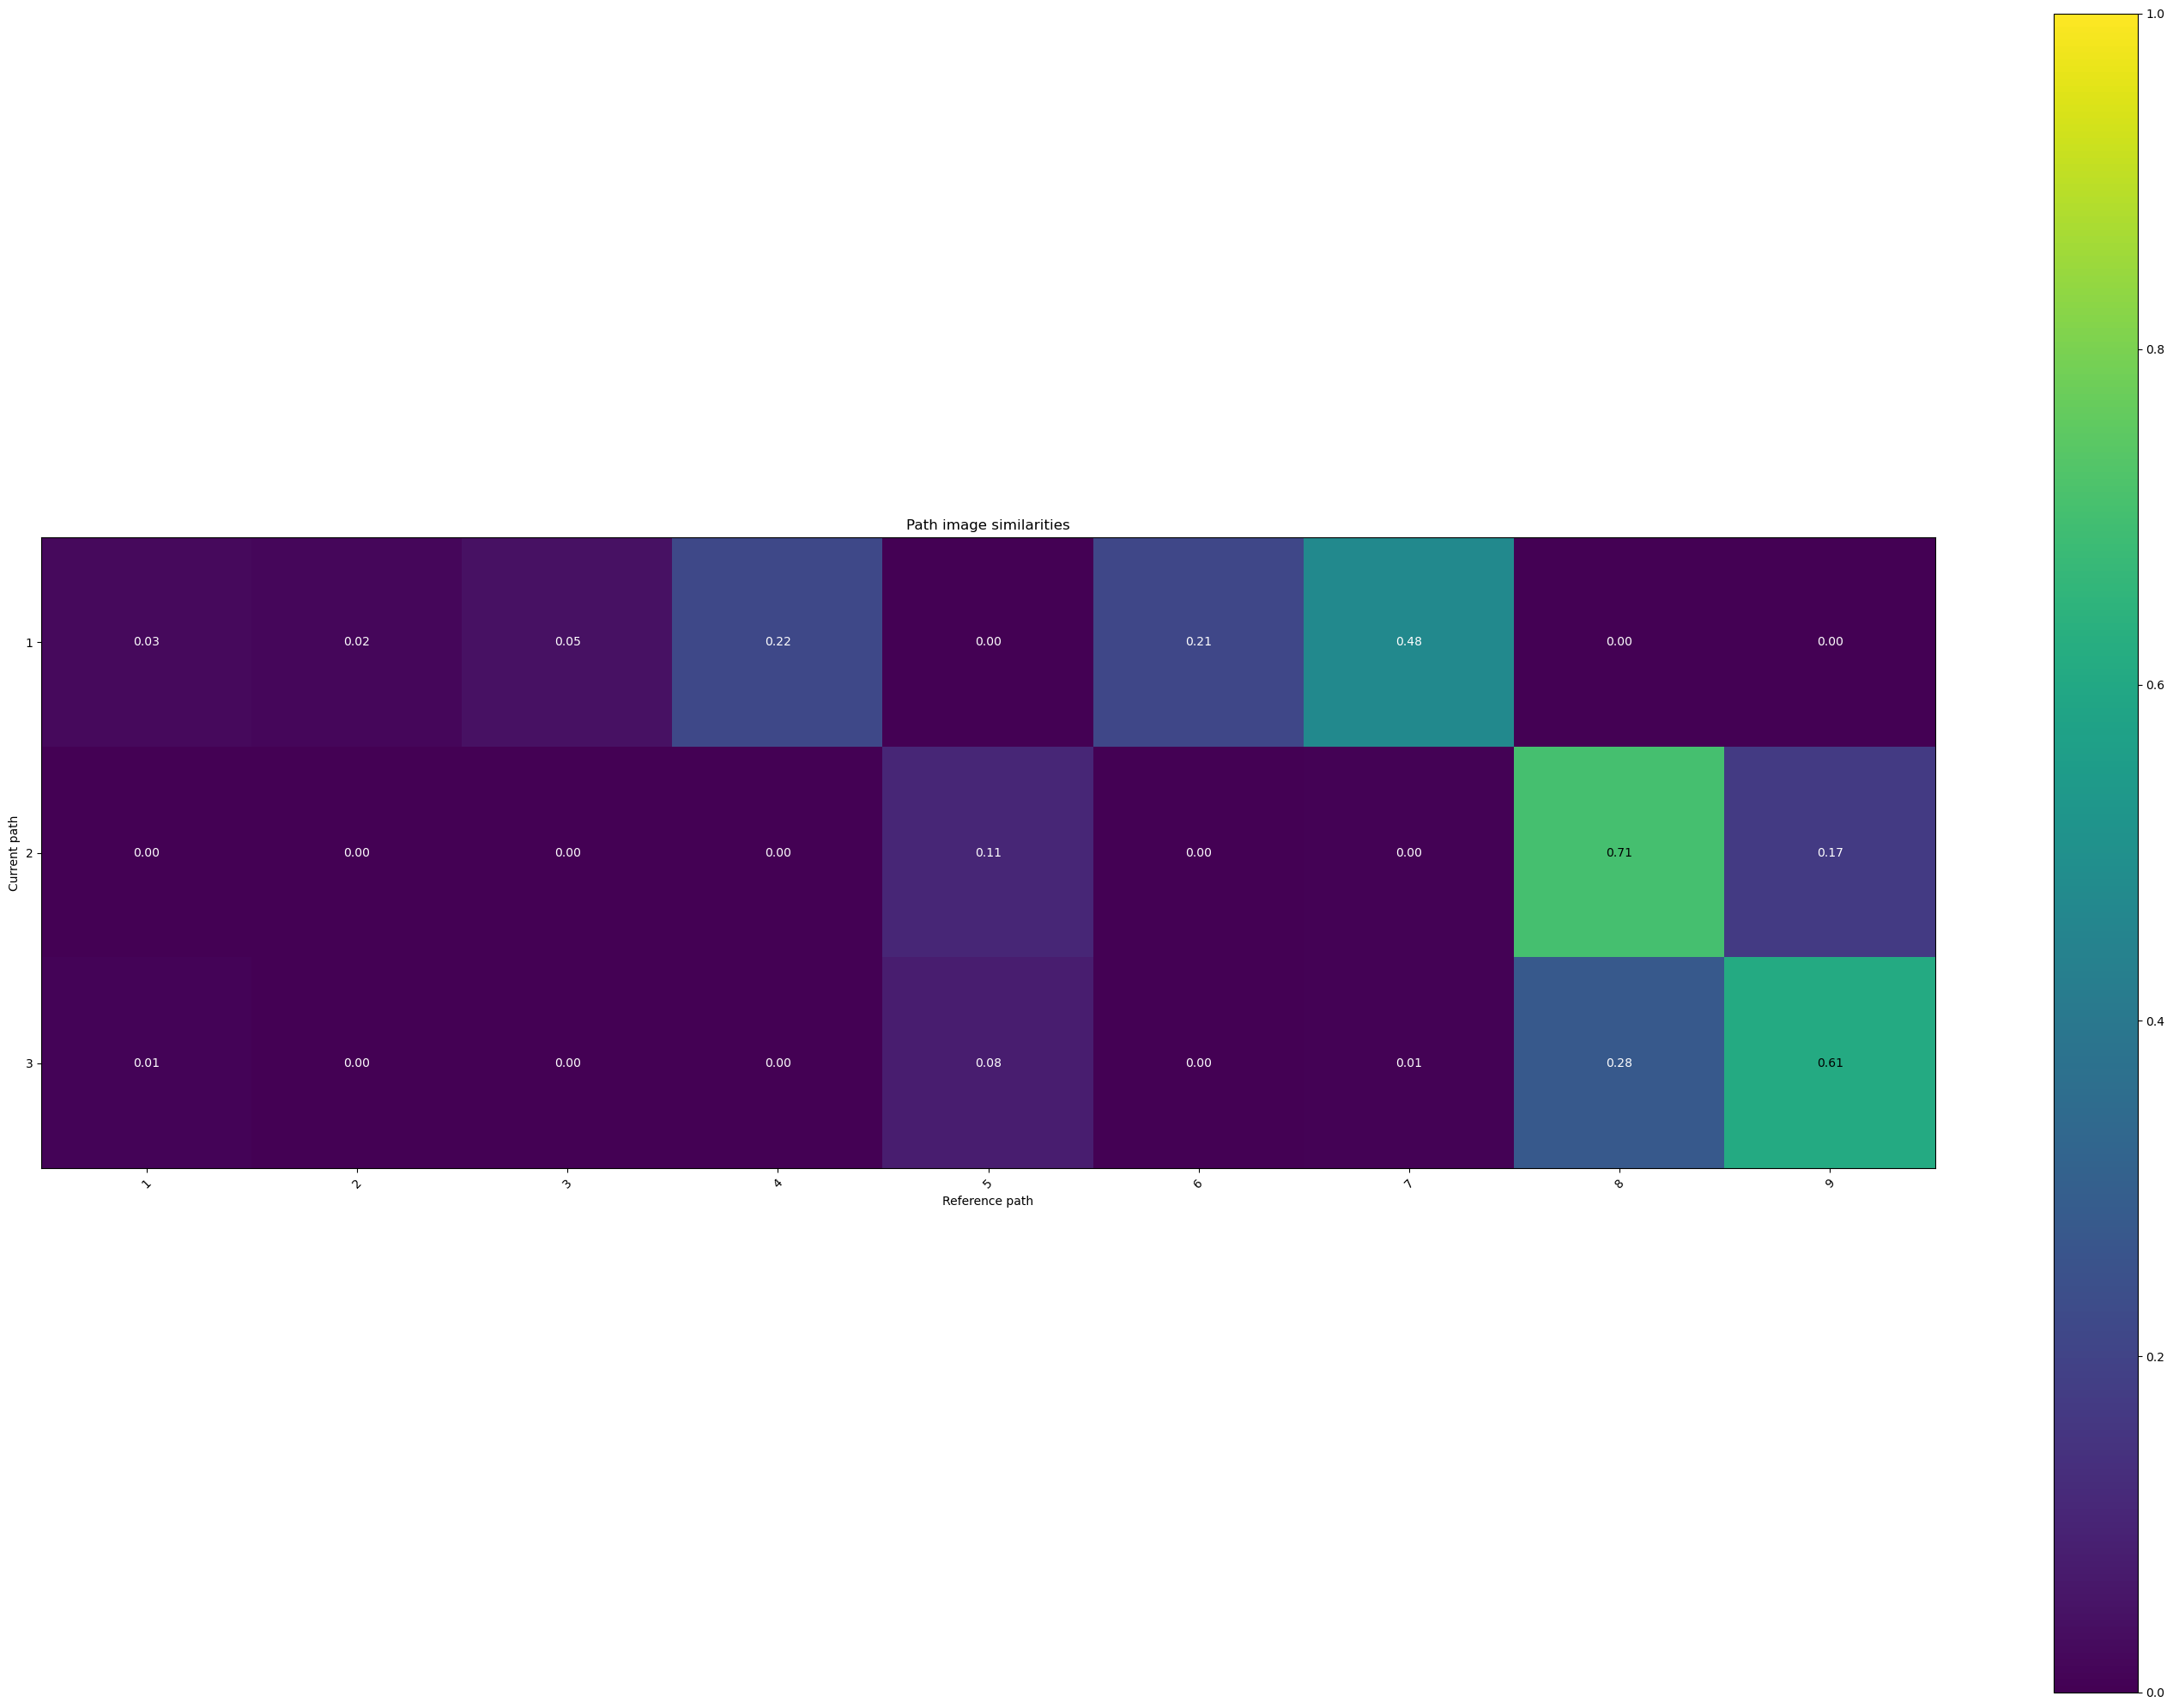

In [3]:
probs = pc.compare_paths(ref_imgs, cur_imgs[0:3])
pc.visualize_probs(probs)
probs = pc.compare_paths(ref_imgs, cur_imgs[3:6])
pc.visualize_probs(probs)
probs = pc.compare_paths(ref_imgs, cur_imgs[6:9])
pc.visualize_probs(probs)
probs = pc.compare_paths(ref_imgs, cur_imgs[9:12])
pc.visualize_probs(probs)

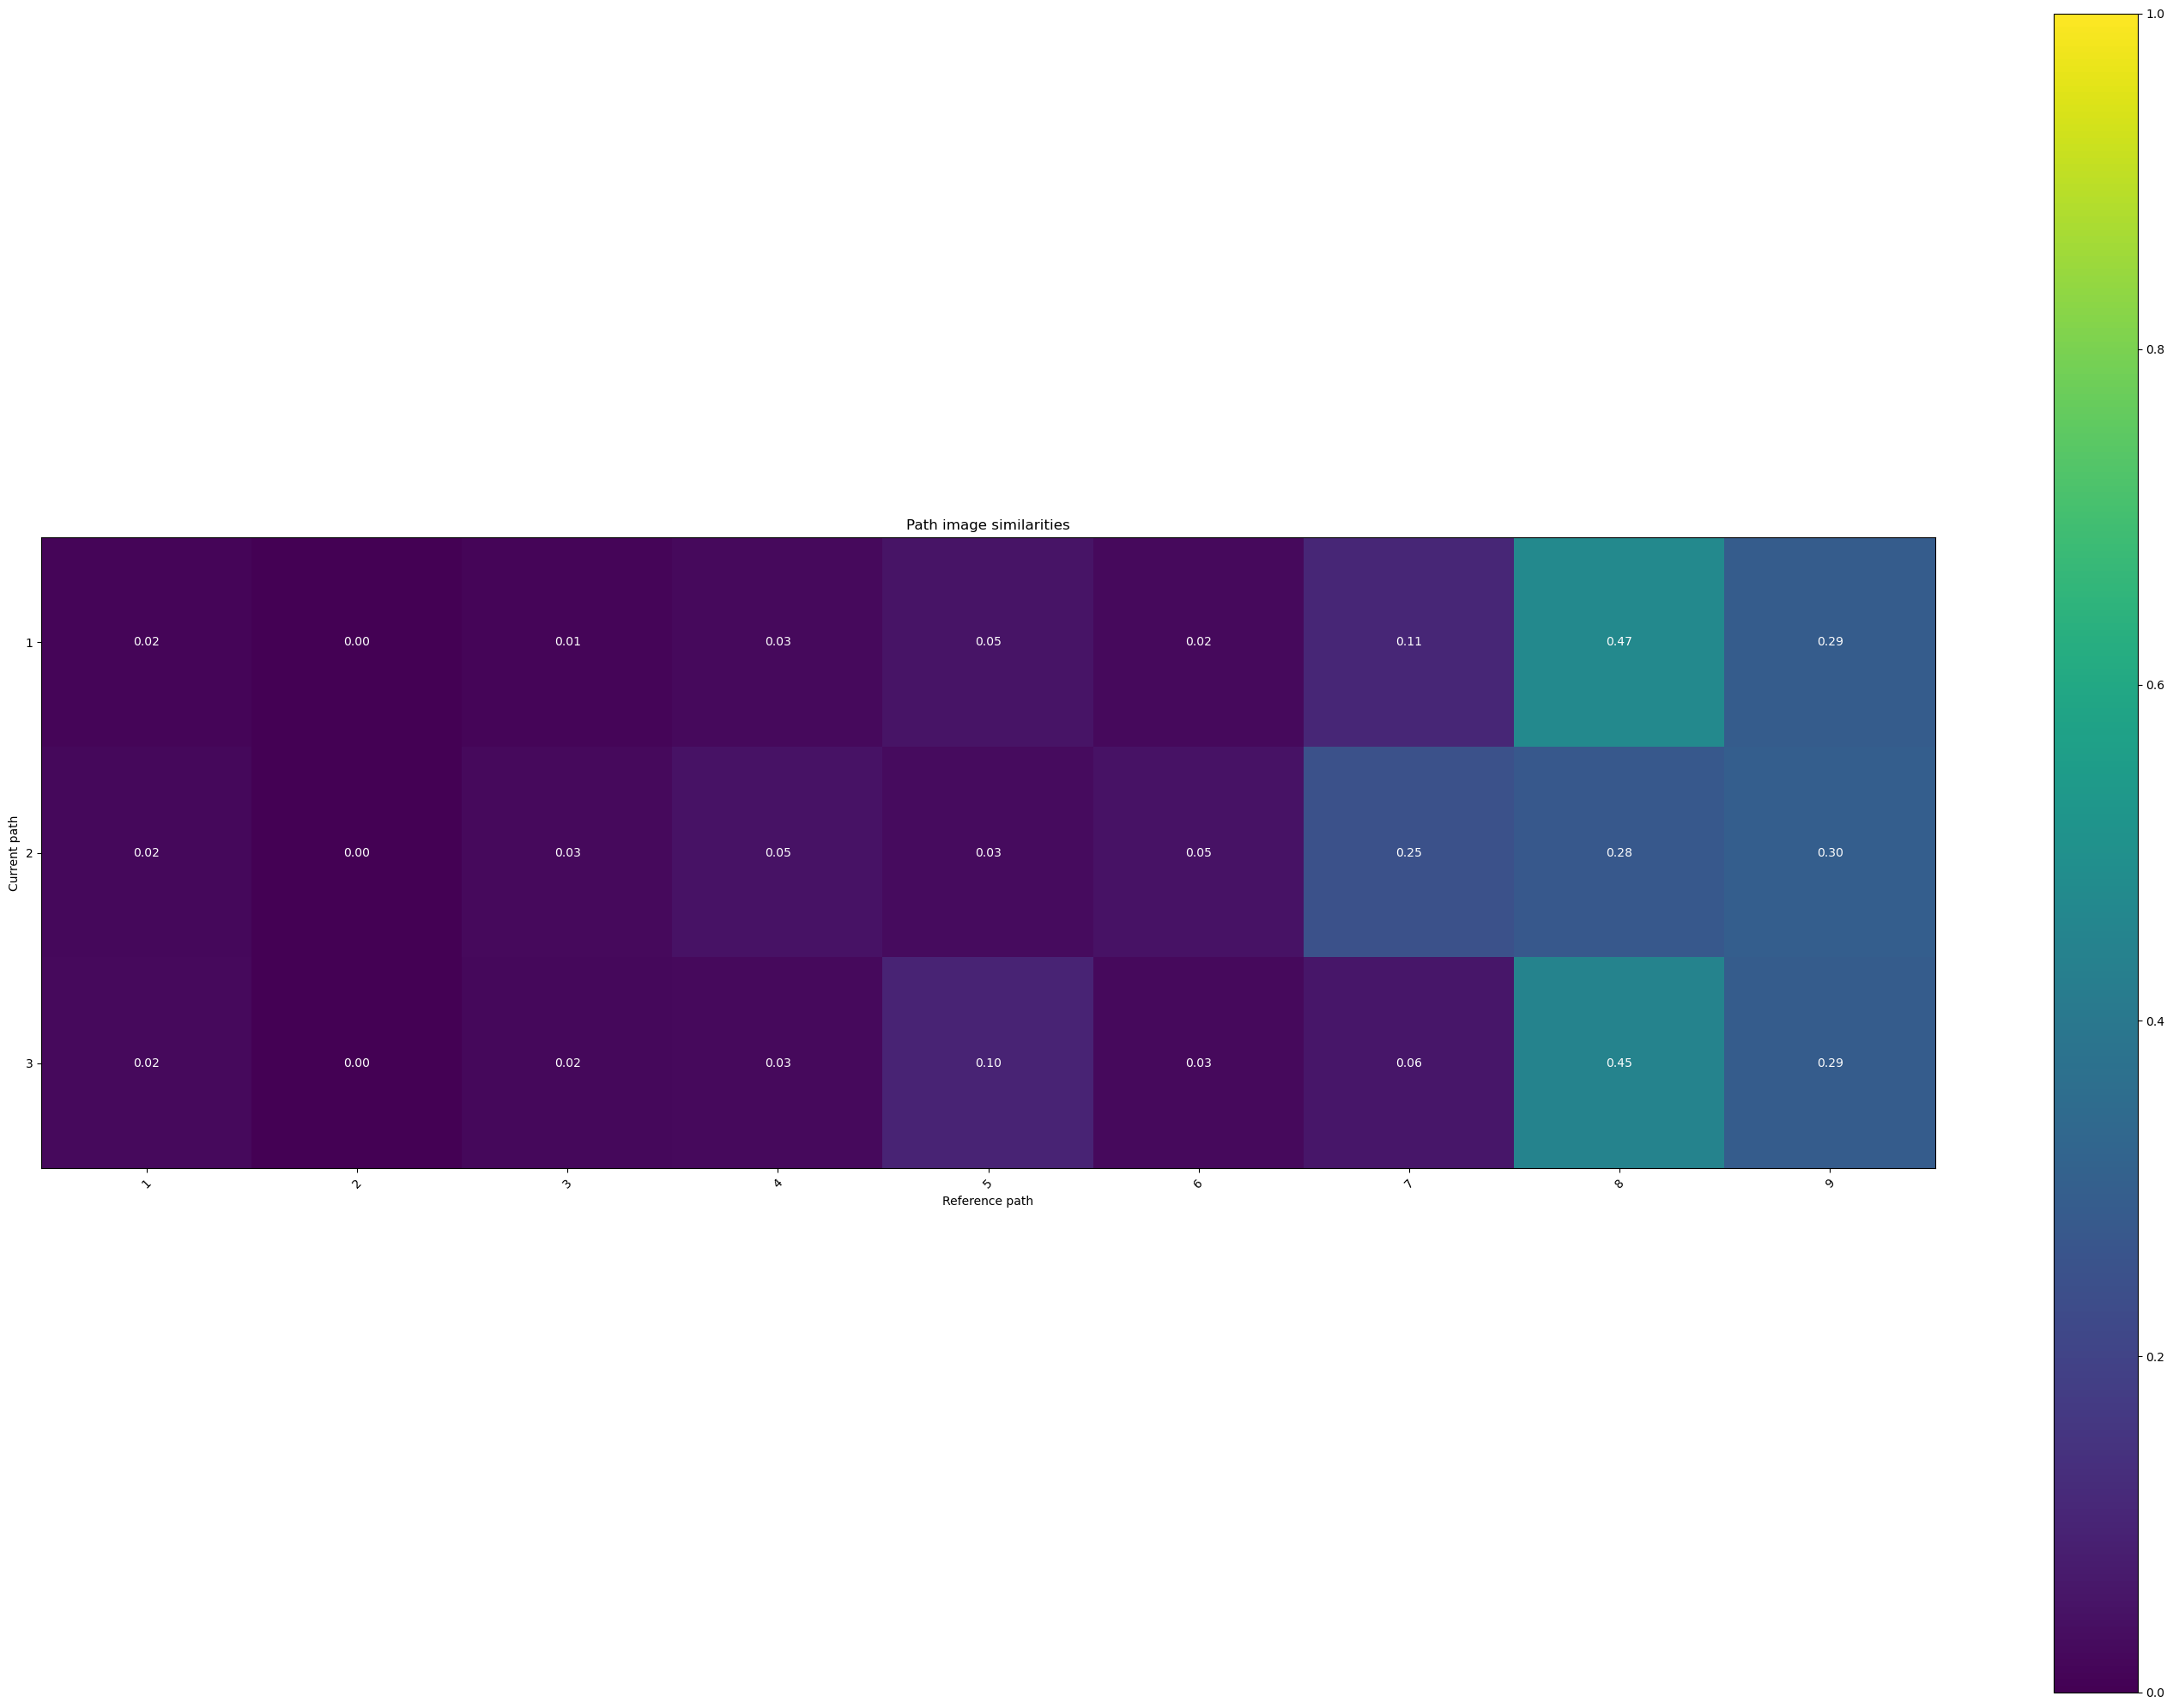

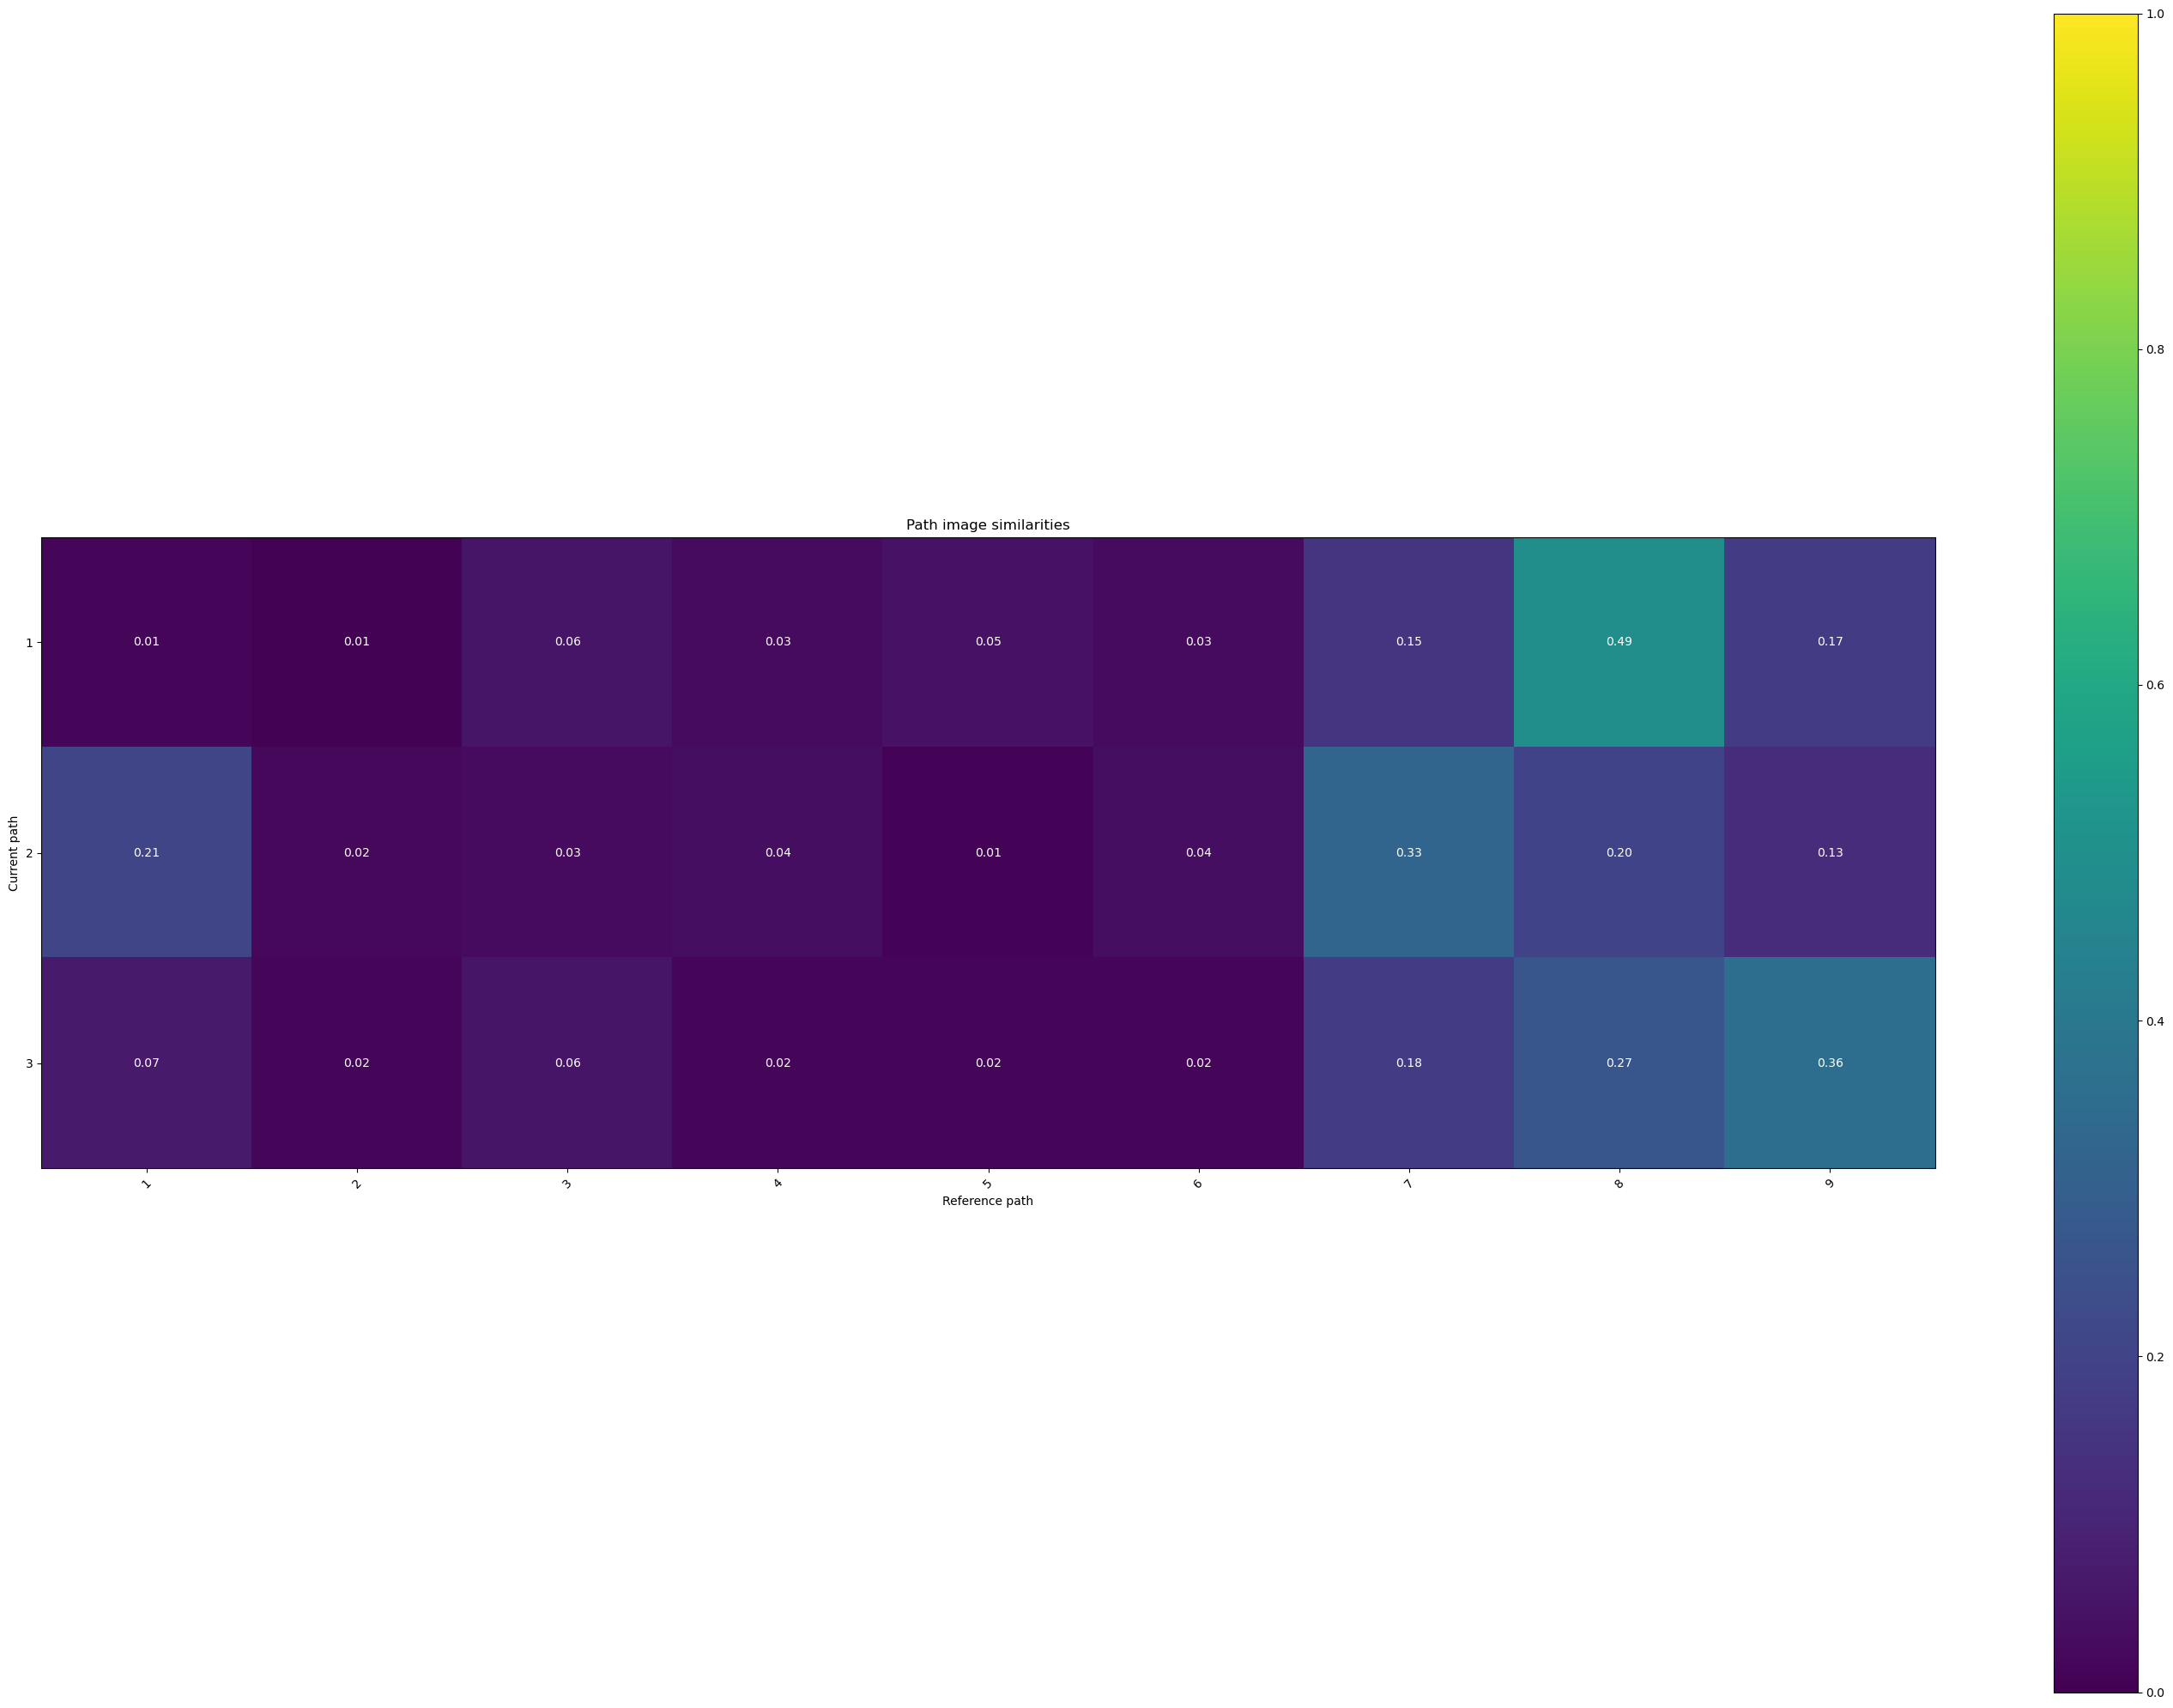

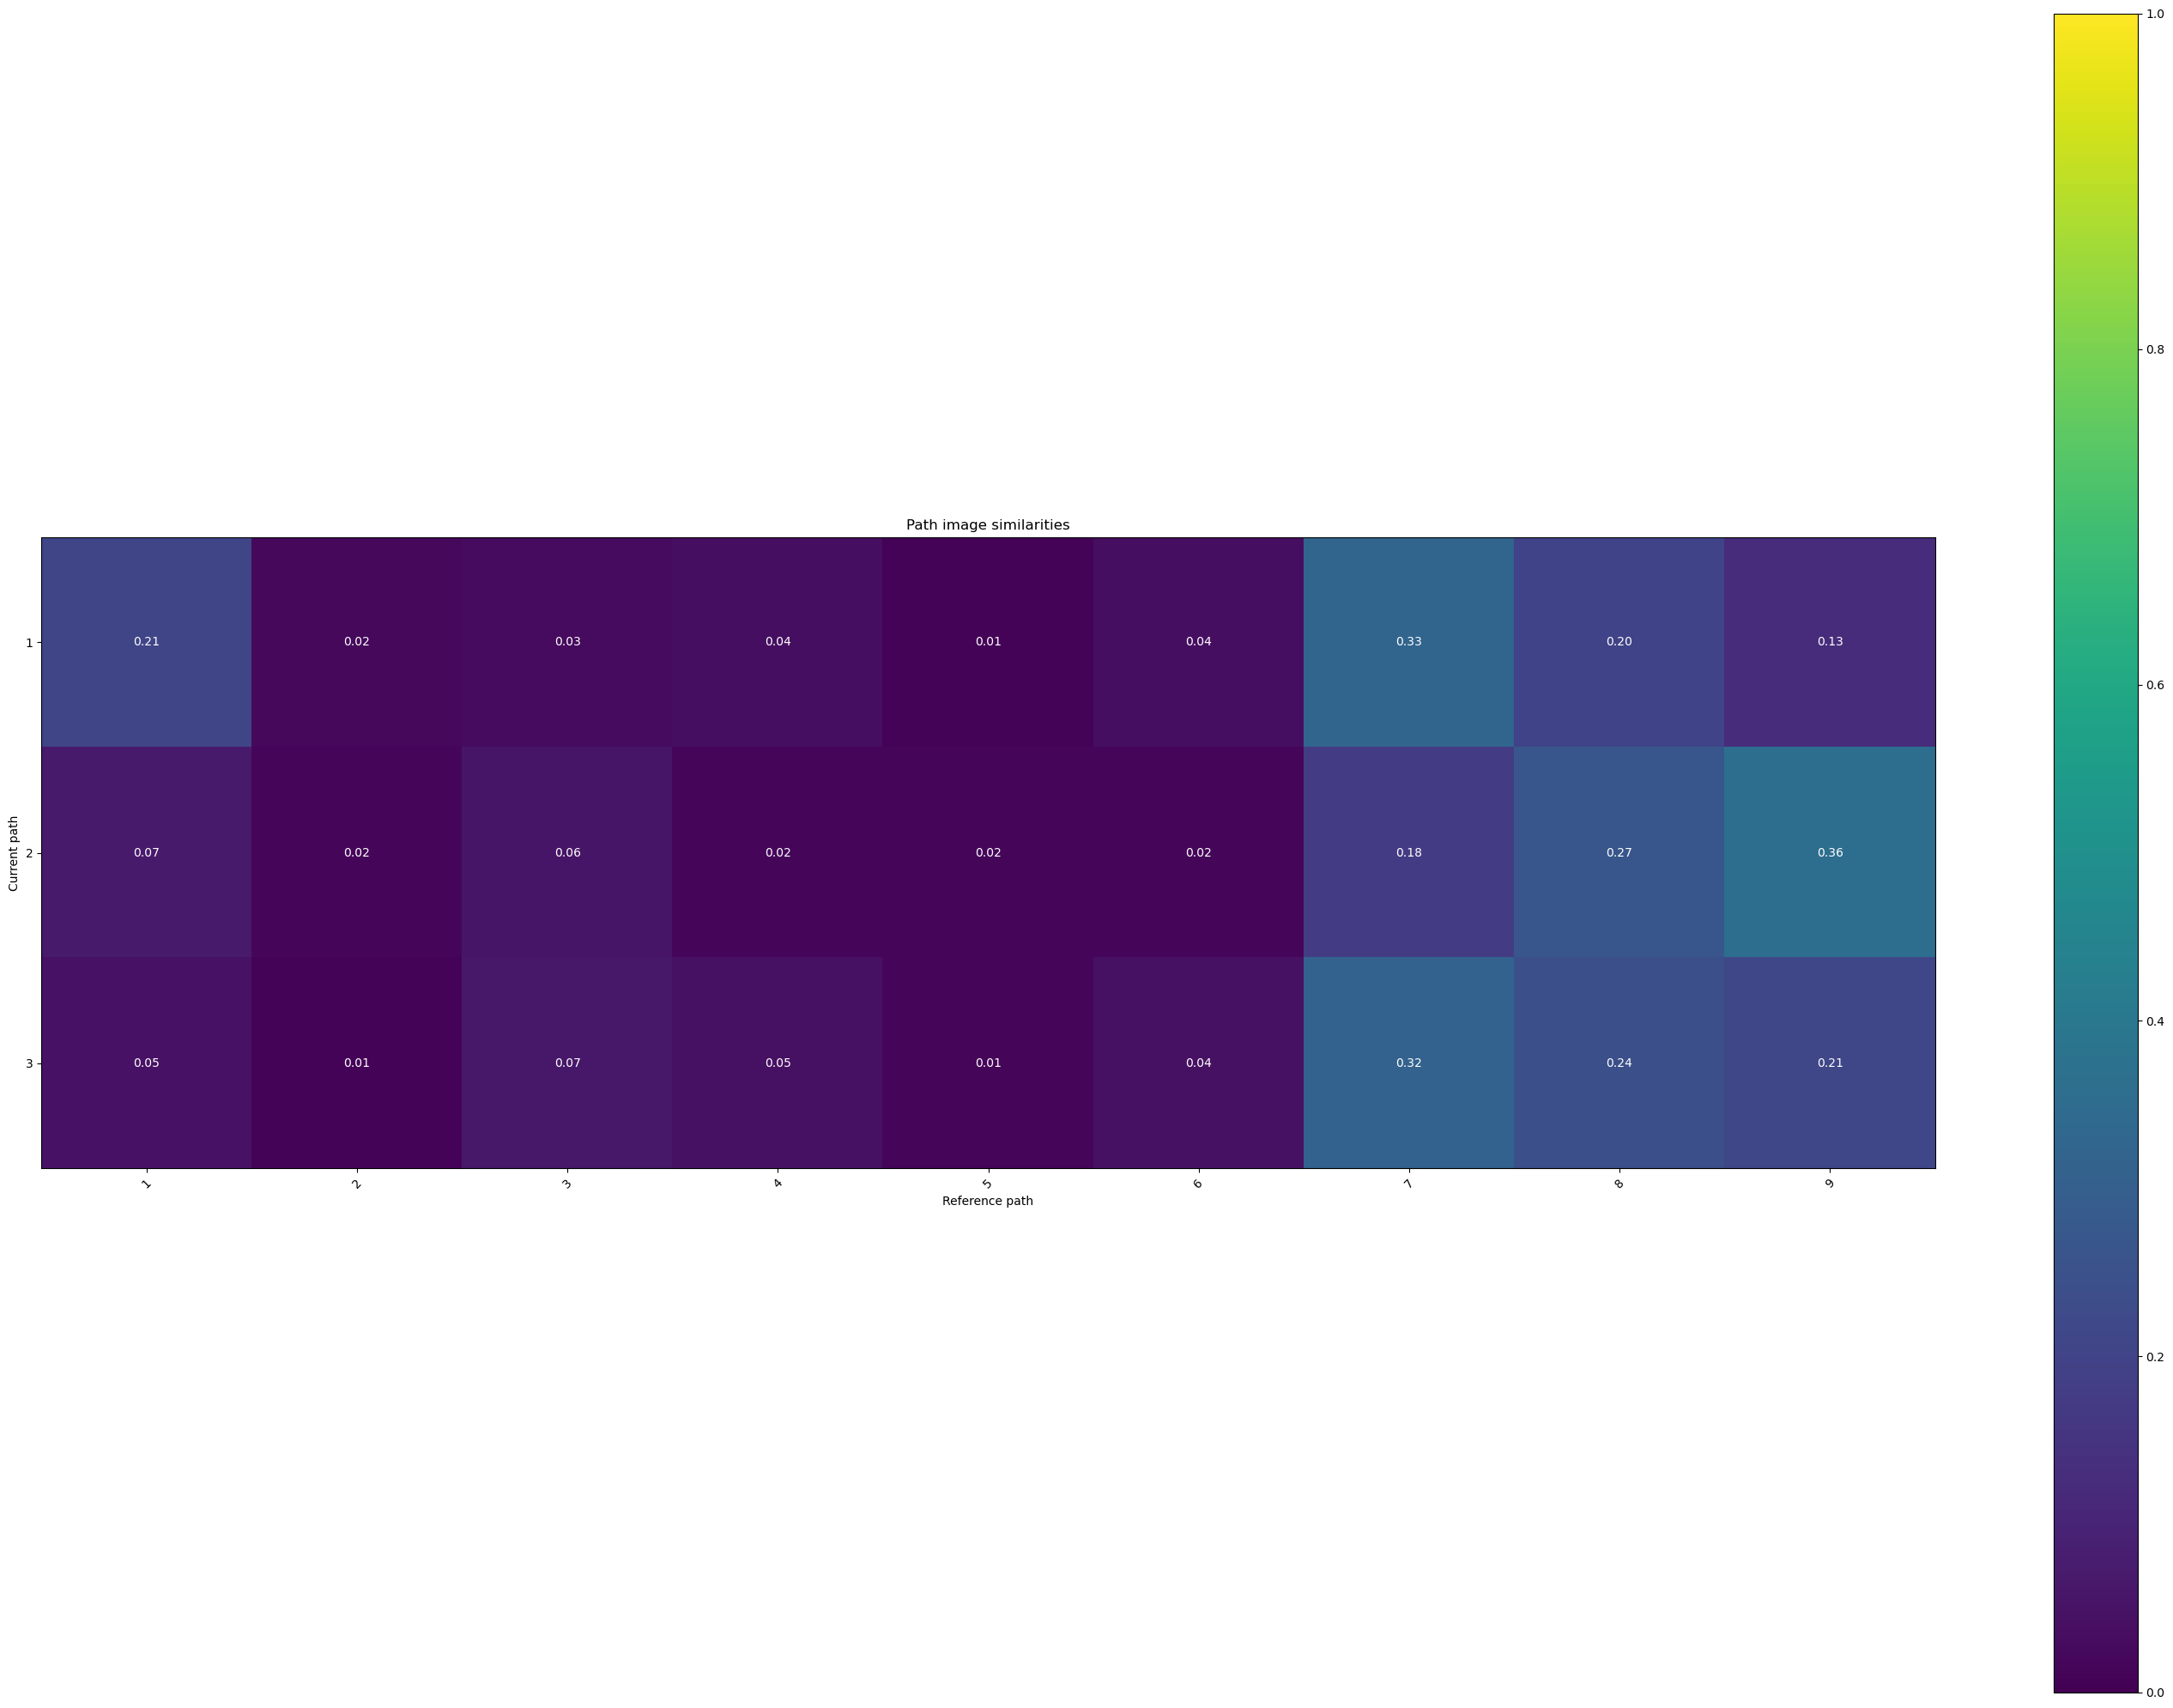

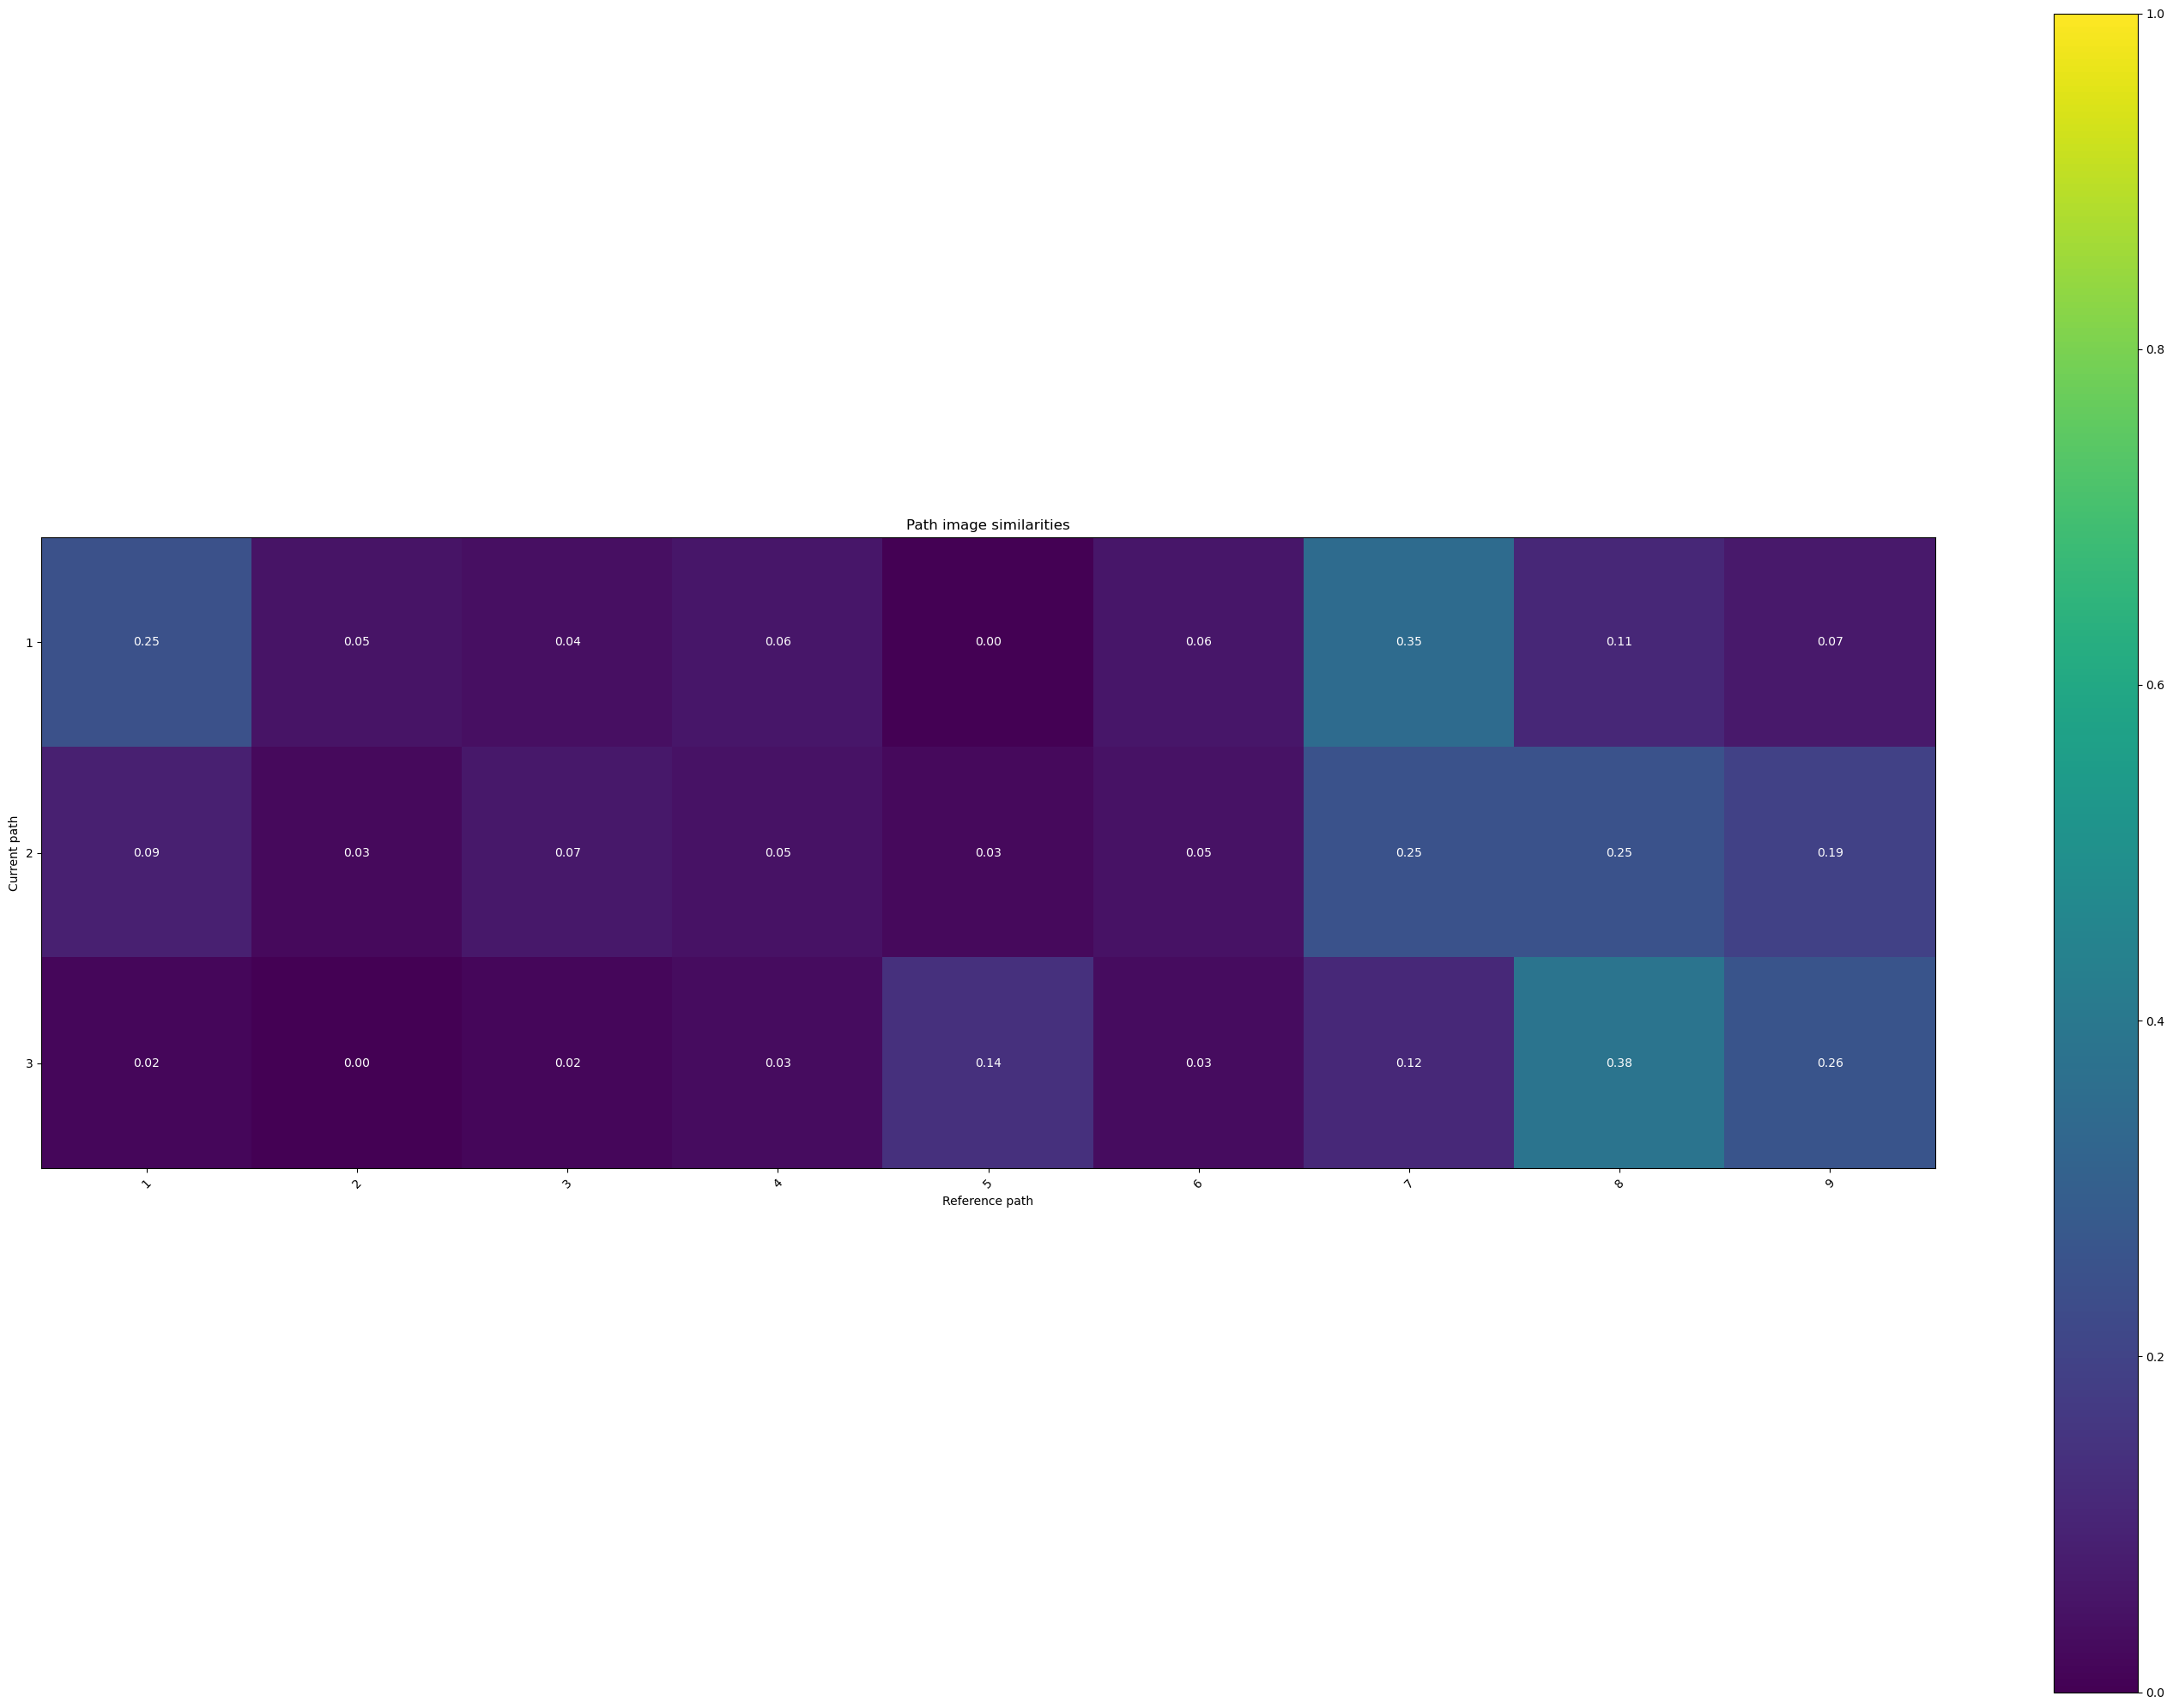

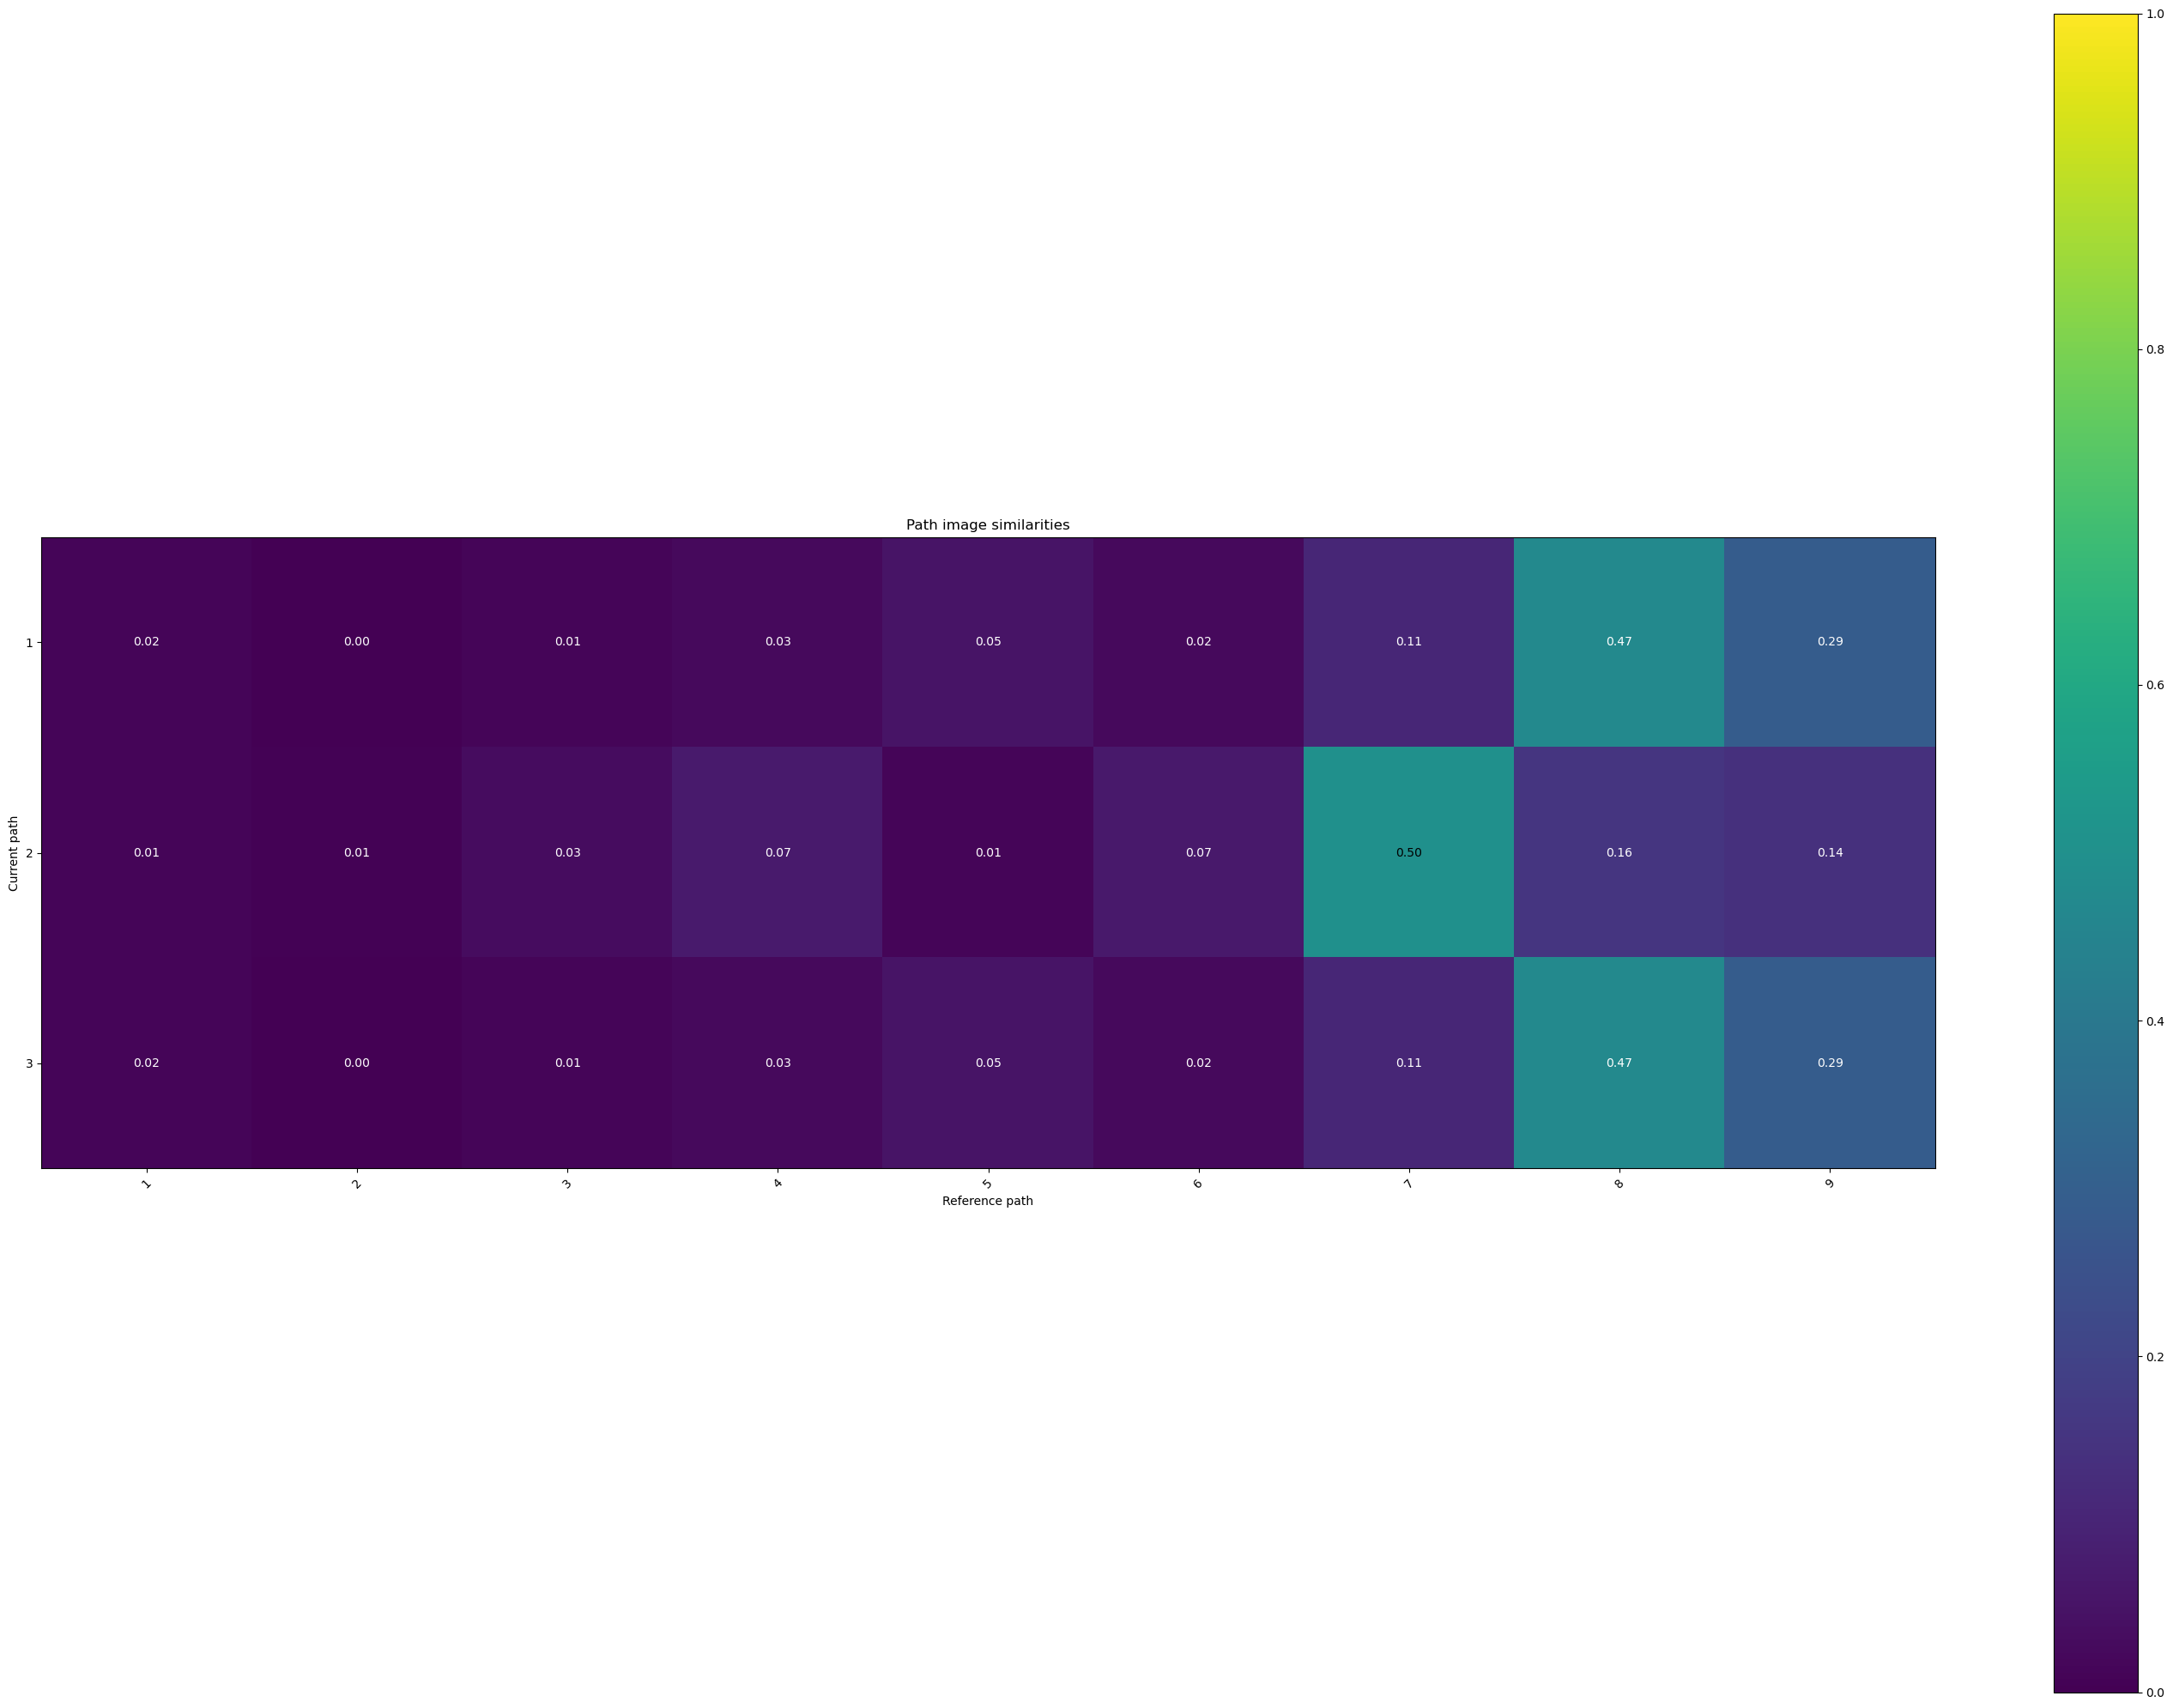

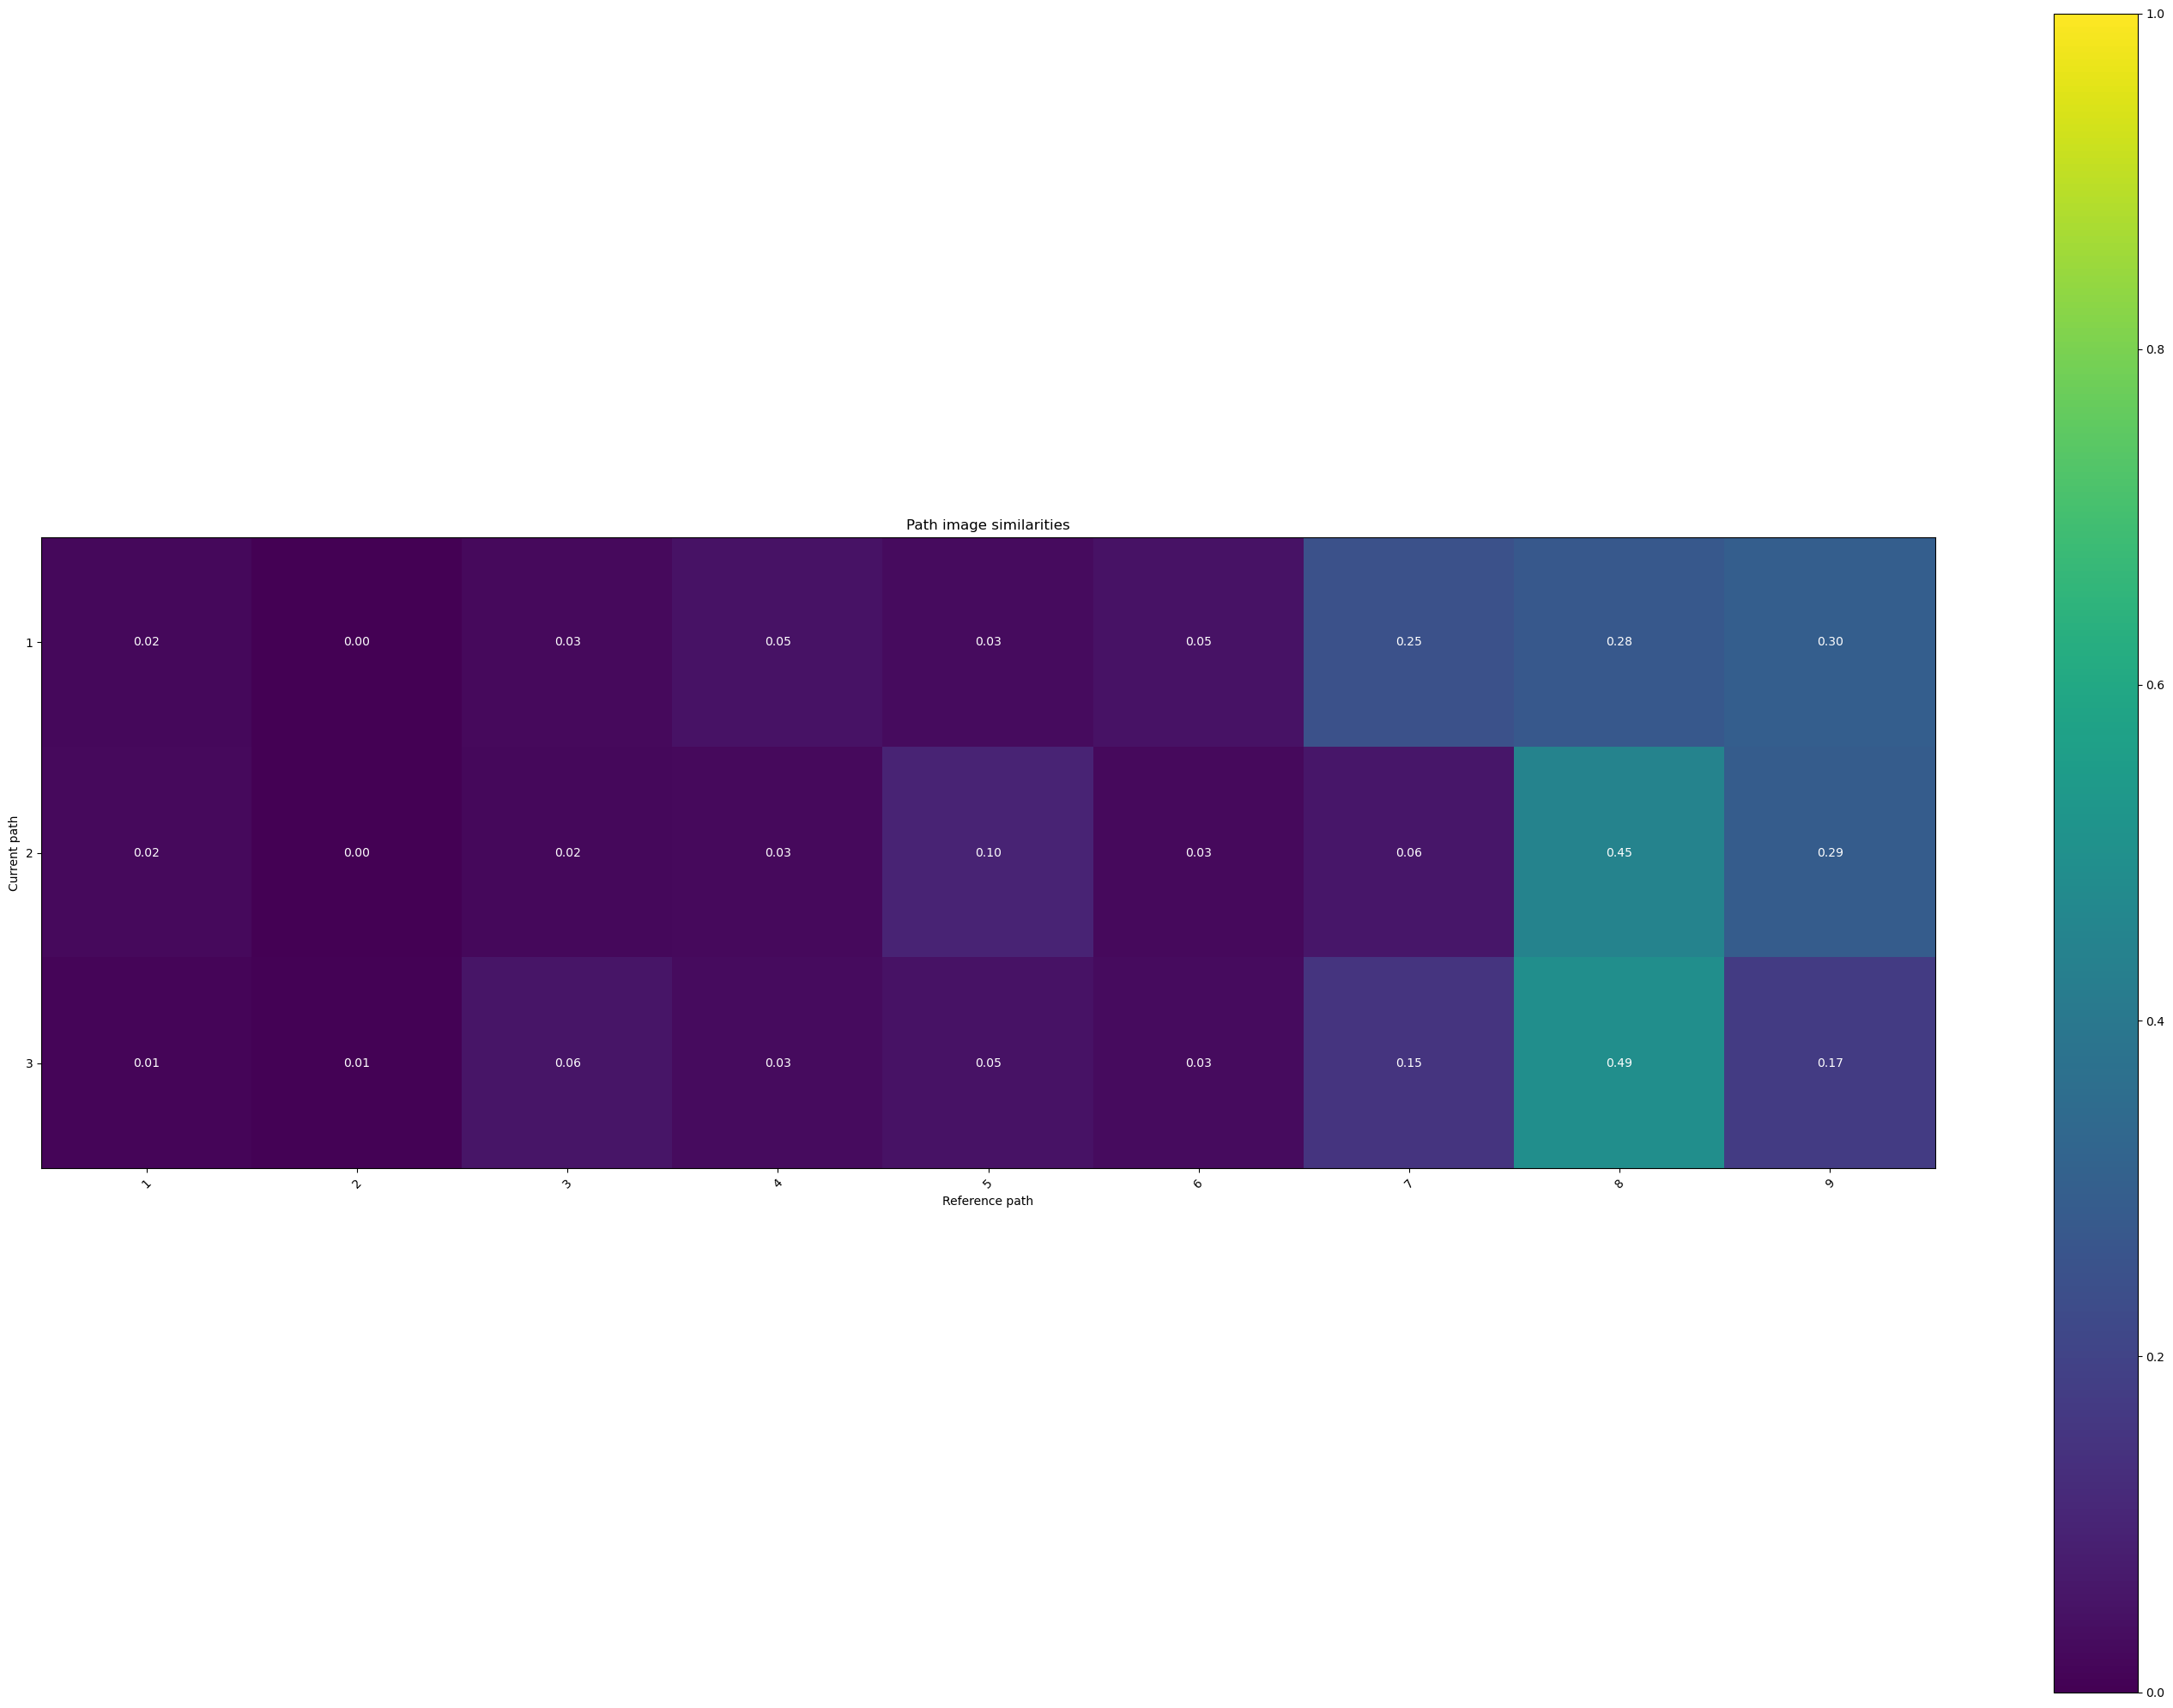

In [4]:
probs = pc.compare_paths(ref_imgs, alien_imgs[0:3])
pc.visualize_probs(probs)
probs = pc.compare_paths(ref_imgs, alien_imgs[3:6])
pc.visualize_probs(probs)
probs = pc.compare_paths(ref_imgs, alien_imgs[6:9])
pc.visualize_probs(probs)
probs = pc.compare_paths(ref_imgs, alien_imgs[9:12])
pc.visualize_probs(probs)
probs = pc.compare_paths(ref_imgs, alien_imgs[12:15])
pc.visualize_probs(probs)
probs = pc.compare_paths(ref_imgs, alien_imgs[15:18])
pc.visualize_probs(probs)

In [9]:
probs

tensor([[1.6816e-44, 9.3152e-02, 5.3804e-02, 3.8116e-02, 1.3028e-03, 3.7807e-02,
         2.4409e-02, 1.8173e-03, 2.5652e-03, 2.2984e-02, 9.4158e-05, 2.3282e-02,
         4.3938e-01, 1.0190e-01, 5.4524e-02, 3.7052e-02, 1.2735e-03, 3.6693e-02,
         2.4396e-02, 1.9048e-03, 3.5534e-03],
        [9.0008e-02, 1.5414e-44, 8.0505e-02, 3.4620e-02, 3.8620e-04, 3.4466e-02,
         1.4460e-02, 4.7366e-04, 4.3008e-04, 3.5052e-02, 5.1675e-05, 3.5384e-02,
         8.8075e-02, 4.1840e-01, 8.3294e-02, 3.4031e-02, 3.6865e-04, 3.3890e-02,
         1.4997e-02, 4.9961e-04, 6.0549e-04],
        [4.2769e-02, 6.6230e-02, 1.2612e-44, 7.7275e-02, 7.0308e-04, 7.6572e-02,
         3.1948e-02, 1.1250e-03, 1.1129e-03, 2.4542e-02, 8.4621e-05, 2.4574e-02,
         4.0419e-02, 7.4324e-02, 3.4940e-01, 7.6895e-02, 7.0044e-04, 7.5983e-02,
         3.3198e-02, 1.2195e-03, 9.2913e-04],
        [1.8297e-02, 1.7200e-02, 4.6667e-02, 8.4078e-45, 4.0372e-04, 2.1374e-01,
         9.1786e-02, 7.7559e-04, 6.2999e-04, 2.1048e